# Airport Congestion Forecasting at Madrid-Barajas
## Complete Pipeline: Data Collection, Feature Engineering, ML Models & Geospatial Analysis

**University Group Project** - Predicting next-hour and next-3-hour airport congestion pressure at Adolfo Suarez Madrid-Barajas Airport (MAD/LEMD) using flight tracking, weather, and calendar signals.

### Pipeline Overview
- **Part 1** (Cells 1-10): Data collection from FlightRadar24, Open-Meteo, holidays, OpenSky
- **Part 2** (Cells 11-22): ACPS target, feature engineering, EDA, baselines, SARIMAX
- **Part 3** (Cells 23-32): ML models, geospatial analysis, evaluation, final outputs

### How to Run
1. Select kernel: **Airport Congestion (Python 3.10)**
2. Run all cells top-to-bottom (Cell > Run All)
3. First run fetches data from APIs (needs internet). Subsequent runs use cache.

---
---
# Part 1: Data Collection & Validation

##  Data Foundation: Collection, Exploration & Validation

## Project
**Forecasting Airport Congestion at Madrid-Barajas Using Flight Tracking, Weather, and Calendar Signals**

## Purpose
This notebook is the complete data foundation for the project. It:
1. Documents the project scope, research question, and target definition
2. Collects data from all sources (flights, weather, holidays, airport metadata)
3. Explores each dataset with visualizations
4. Validates data quality and documents any issues
5. Saves all raw data for downstream feature engineering

## Research Question
**Can we forecast airport congestion pressure at Madrid-Barajas 1h and 3h ahead using flight movement, weather, and calendar signals?**

## Target
- **Airport:** Adolfo Suarez Madrid-Barajas (LEMD / MAD)
- **Metric:** Airport Congestion Pressure Score (ACPS)
- **Horizons:** t+1 hour, t+3 hours
- **Tasks:** Regression (continuous ACPS) + Classification (Low/Medium/High)

## Outputs
- `data/raw/flightradar/fr24_arrivals_board.parquet`
- `data/raw/flightradar/fr24_departures_board.parquet`
- `data/raw/open_meteo/weather_hourly_LEMD.parquet`
- `data/raw/holidays/spain_holidays_*.json`
- `data/raw/ourairports/airport_reference.parquet`
- `data/raw/opensky/state_vectors_*.parquet`
- `data/raw/flightradar/live_snapshots/snapshot_*.json`

In [1]:
# === Setup ===
import sys
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project root
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    AIRPORT, AIRPORT_ICAO, AIRPORT_IATA, AIRPORT_LAT, AIRPORT_LON,
    AIRPORT_TZ, BOUNDING_BOX, ANALYSIS_BANDS,
    DATA_START_DATE, DATA_END_DATE, PATHS, get_path
)

# Display settings
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

FIGURES_DIR = Path(get_path('figures'))

print(f"Airport: {AIRPORT['name']} ({AIRPORT_ICAO}/{AIRPORT_IATA})")
print(f"Coordinates: ({AIRPORT_LAT}, {AIRPORT_LON})")
print(f"Timezone: {AIRPORT_TZ}")
print(f"Target data range: {DATA_START_DATE} to {DATA_END_DATE}")

Airport: Adolfo Suarez Madrid-Barajas (LEMD/MAD)
Coordinates: (40.4936, -3.5668)
Timezone: Europe/Madrid
Target data range: 2025-03-01 to 2026-03-27


---
## 1. Data Source Strategy

| Source | Type | What It Provides | Status |
|--------|------|-----------------|--------|
| **FlightRadar24** (unofficial wrapper) | Airport board | Arrivals/departures with scheduled & actual times | Primary flight source |
| **OpenSky Network** | State vectors | Live aircraft positions near airport | Geospatial enrichment |
| **Open-Meteo** | Historical API | 12 months hourly weather | Core exogenous source |
| **Nager.Date** | REST API | Spanish public holidays | Calendar features |
| **OurAirports** | Static CSV | Airport coordinates and metadata | Reference data |

### Why this combination?
- **FlightRadar24** provides real arrival/departure data with timestamps and status
- **OpenSky** state vectors (anonymous access) give aircraft positions for geospatial analysis
- **Open-Meteo** provides robust hourly weather history for the full study period
- Together they cover time-series, geospatial, and exogenous variable requirements

### Data access notes
- OpenSky historical flights endpoint requires research-tier access (`403: You cannot access historical flights`)
- FlightRadar24 board provides ~36h window of scheduled and actual flight data
- For extended historical analysis, periodic collection or OpenSky Trino access would be needed
- This limitation is documented honestly in the report

---
## 2. Flight Data Collection (FlightRadar24 Airport Board)

In [2]:
from src.data.fetch_flightradar import fetch_airport_board

# Fetch full airport board (paginated, ~1200+ flights each direction)
# Cached: if parquet files already exist, load them instead
fr24_dir = Path(get_path('raw_flightradar')).parent  # data/raw/flightradar
arr_path = fr24_dir / 'fr24_arrivals_board.parquet'
dep_path = fr24_dir / 'fr24_departures_board.parquet'

if arr_path.exists() and dep_path.exists():
    print("Loading cached FR24 board data...")
    arrivals = pd.read_parquet(arr_path)
    departures = pd.read_parquet(dep_path)
else:
    print("Fetching FR24 airport board (this takes ~15 seconds)...")
    arrivals, departures = fetch_airport_board('MAD', max_pages=15)

print(f"\nArrivals: {len(arrivals)} flights")
print(f"Departures: {len(departures)} flights")

Loading cached FR24 board data...

Arrivals: 1260 flights
Departures: 1246 flights


In [3]:
# Convert timestamps and explore arrivals
arrivals['sched_arrival_dt'] = pd.to_datetime(arrivals['scheduled_arrival'], unit='s', utc=True)
arrivals['real_arrival_dt'] = pd.to_datetime(arrivals['real_arrival'], unit='s', utc=True, errors='coerce')
arrivals['sched_departure_dt'] = pd.to_datetime(arrivals['scheduled_departure'], unit='s', utc=True, errors='coerce')

print("=== Arrivals Overview ===")
print(f"Time range: {arrivals['sched_arrival_dt'].min()} to {arrivals['sched_arrival_dt'].max()}")
print(f"Unique origin airports: {arrivals['origin_iata'].nunique()}")
print(f"Flights with real arrival time: {arrivals['real_arrival_dt'].notna().sum()}")
print(f"\nStatus distribution:")
print(arrivals['status_text'].value_counts().head(10))
print(f"\nTop 10 origin airports:")
print(arrivals['origin_iata'].value_counts().head(10))

FloatingPointError: overflow encountered in multiply

In [ ]:
# Convert timestamps and explore departures
departures['sched_departure_dt'] = pd.to_datetime(departures['scheduled_departure'], unit='s', utc=True)
departures['real_departure_dt'] = pd.to_datetime(departures['real_departure'], unit='s', utc=True, errors='coerce')

print("=== Departures Overview ===")
print(f"Time range: {departures['sched_departure_dt'].min()} to {departures['sched_departure_dt'].max()}")
print(f"Unique destination airports: {departures['dest_iata'].nunique()}")
print(f"Flights with real departure time: {departures['real_departure_dt'].notna().sum()}")
print(f"\nTop 10 destination airports:")
print(departures['dest_iata'].value_counts().head(10))

=== Departures Overview ===
Time range: 2026-03-27 18:25:00+00:00 to 2026-03-29 06:15:00+00:00
Unique destination airports: 167
Flights with real departure time: 0

Top 10 destination airports:
dest_iata
LPA    55
PMI    45
TFN    38
LIS    36
ORY    35
FRA    33
FCO    33
BCN    31
MUC    29
LHR    29
Name: count, dtype: int64


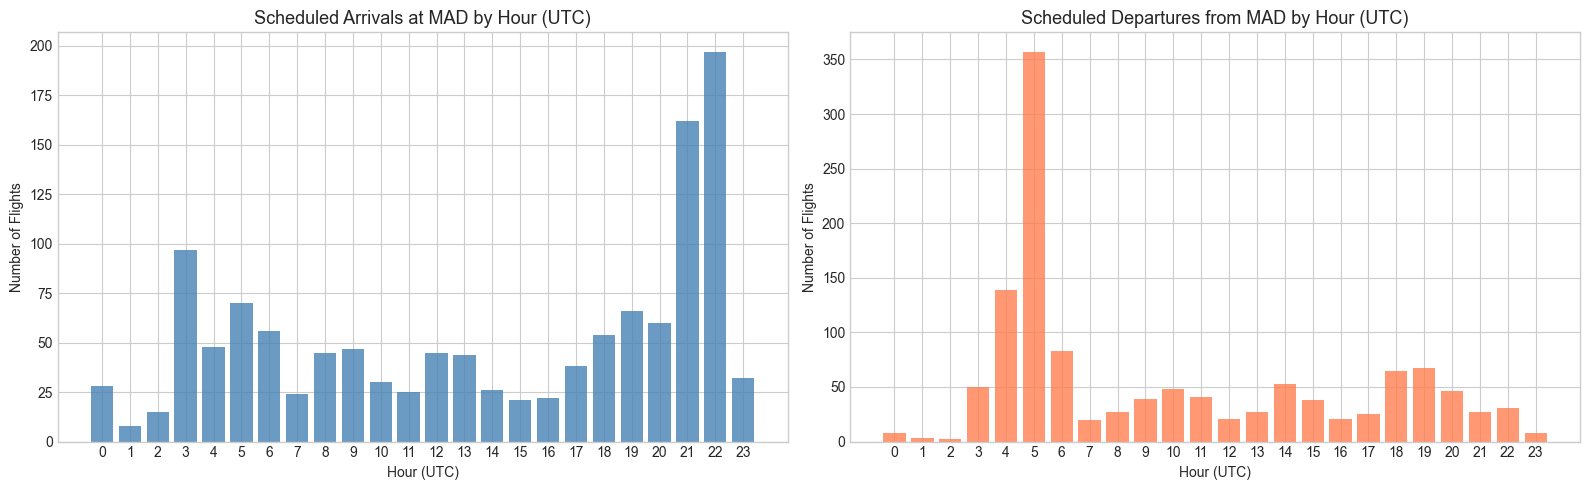

Saved: outputs/figures/hourly_flight_distribution.png


In [ ]:
# Hourly flight distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Arrivals by hour
arr_hours = arrivals['sched_arrival_dt'].dt.hour.value_counts().sort_index()
axes[0].bar(arr_hours.index, arr_hours.values, color='steelblue', alpha=0.8)
axes[0].set_title(f'Scheduled Arrivals at {AIRPORT_IATA} by Hour (UTC)', fontsize=13)
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Number of Flights')
axes[0].set_xticks(range(0, 24))

# Departures by hour
dep_hours = departures['sched_departure_dt'].dt.hour.value_counts().sort_index()
axes[1].bar(dep_hours.index, dep_hours.values, color='coral', alpha=0.8)
axes[1].set_title(f'Scheduled Departures from {AIRPORT_IATA} by Hour (UTC)', fontsize=13)
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Number of Flights')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hourly_flight_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print("Saved: outputs/figures/hourly_flight_distribution.png")

In [ ]:
# Hourly movement counts (combined arrivals + departures)
# This is the foundation for the ACPS target
arr_hourly = (
    arrivals.set_index('sched_arrival_dt')
    .resample('h').size()
    .rename('arrivals')
)
dep_hourly = (
    departures.set_index('sched_departure_dt')
    .resample('h').size()
    .rename('departures')
)

hourly_movements = pd.DataFrame({'arrivals': arr_hourly, 'departures': dep_hourly}).fillna(0).astype(int)
hourly_movements['movements'] = hourly_movements['arrivals'] + hourly_movements['departures']
hourly_movements.index.name = 'timestamp'

print(f"Hourly movements table: {len(hourly_movements)} hours")
print(f"Average movements/hour: {hourly_movements['movements'].mean():.1f}")
print(f"Peak hour: {hourly_movements['movements'].max()} movements")
print(f"\n{hourly_movements.describe().round(1)}")

Hourly movements table: 37 hours
Average movements/hour: 67.7
Peak hour: 392 movements

       arrivals  departures  movements
count      37.0        37.0       37.0
mean       34.1        33.7       67.7
std        32.6        55.4       69.1
min         1.0         0.0        3.0
25%        14.0         6.0       32.0
50%        28.0        25.0       61.0
75%        42.0        37.0       74.0
max       168.0       329.0      392.0


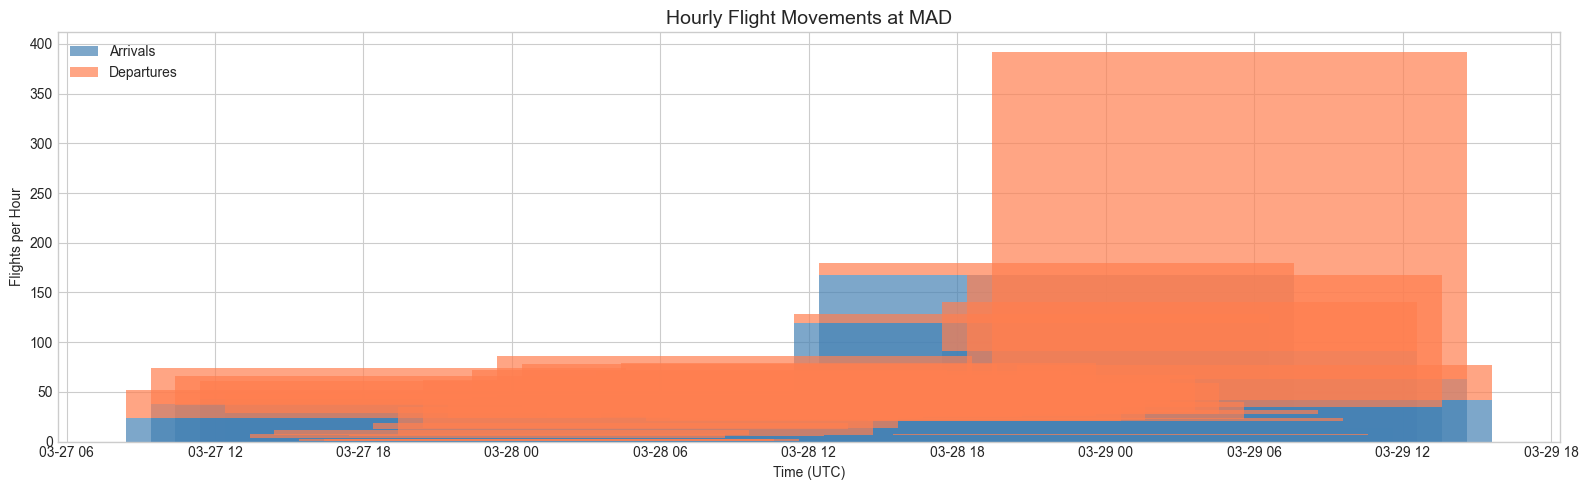

In [ ]:
# Movements over time
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(hourly_movements.index, hourly_movements['arrivals'], label='Arrivals', alpha=0.7, color='steelblue')
ax.bar(hourly_movements.index, hourly_movements['departures'], bottom=hourly_movements['arrivals'],
       label='Departures', alpha=0.7, color='coral')
ax.set_title(f'Hourly Flight Movements at {AIRPORT_IATA}', fontsize=14)
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Flights per Hour')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hourly_movements_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


---
## 3. Weather Data Collection (Open-Meteo)

In [ ]:
from src.data.fetch_open_meteo import fetch_weather

# Fetch 12 months of hourly weather (cached after first run)
weather = fetch_weather()

print(f"Weather data: {len(weather)} hours")
print(f"Date range: {weather['timestamp'].min()} to {weather['timestamp'].max()}")
print(f"Variables: {[c for c in weather.columns if c != 'timestamp']}")
print(f"\nNull counts:")
print(weather.isnull().sum())
print(f"\nBasic stats:")
weather.describe().round(2)

[2026-03-27 19:36:39] src.data.fetch_open_meteo - INFO - Weather data already cached: C:\Users\Ian\FlightScanner_Emerging\data\raw\open_meteo\weather_hourly_LEMD.parquet
Weather data: 9408 hours
Date range: 2025-03-01 00:00:00+00:00 to 2026-03-27 23:00:00+00:00
Variables: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'weather_code', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'cloud_cover']

Null counts:
timestamp               0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
weather_code            0
surface_pressure        0
wind_speed_10m          0
wind_direction_10m      0
wind_gusts_10m          0
cloud_cover             0
dtype: int64

Basic stats:


,temperature_2m,relative_humidity_2m,precipitation,rain,weather_code,surface_pressure,wind_speed_10m,wind_direction_10m,wind_gusts_10m,cloud_cover
count,9408.00,9408.00,9408.00,9408.00,9408.00,9408.00,9408.00,9408.00,9408.00,9408.00
mean,15.21,61.24,0.10,0.09,8.59,944.83,8.29,151.27,20.87,50.69
std,9.45,25.87,0.43,0.42,18.27,5.95,5.33,110.36,11.07,42.73
min,-4.20,6.00,0.00,0.00,0.00,917.20,0.00,0.00,0.70,0.00
25%,7.80,40.00,0.00,0.00,0.00,942.00,4.20,36.00,12.60,2.00
50%,13.10,63.00,0.00,0.00,2.00,945.90,7.10,167.00,19.10,48.00
75%,21.90,86.00,0.00,0.00,3.00,949.00,11.70,233.00,27.70,100.00
max,40.50,100.00,7.00,7.00,75.00,959.60,35.40,360.00,77.80,100.00


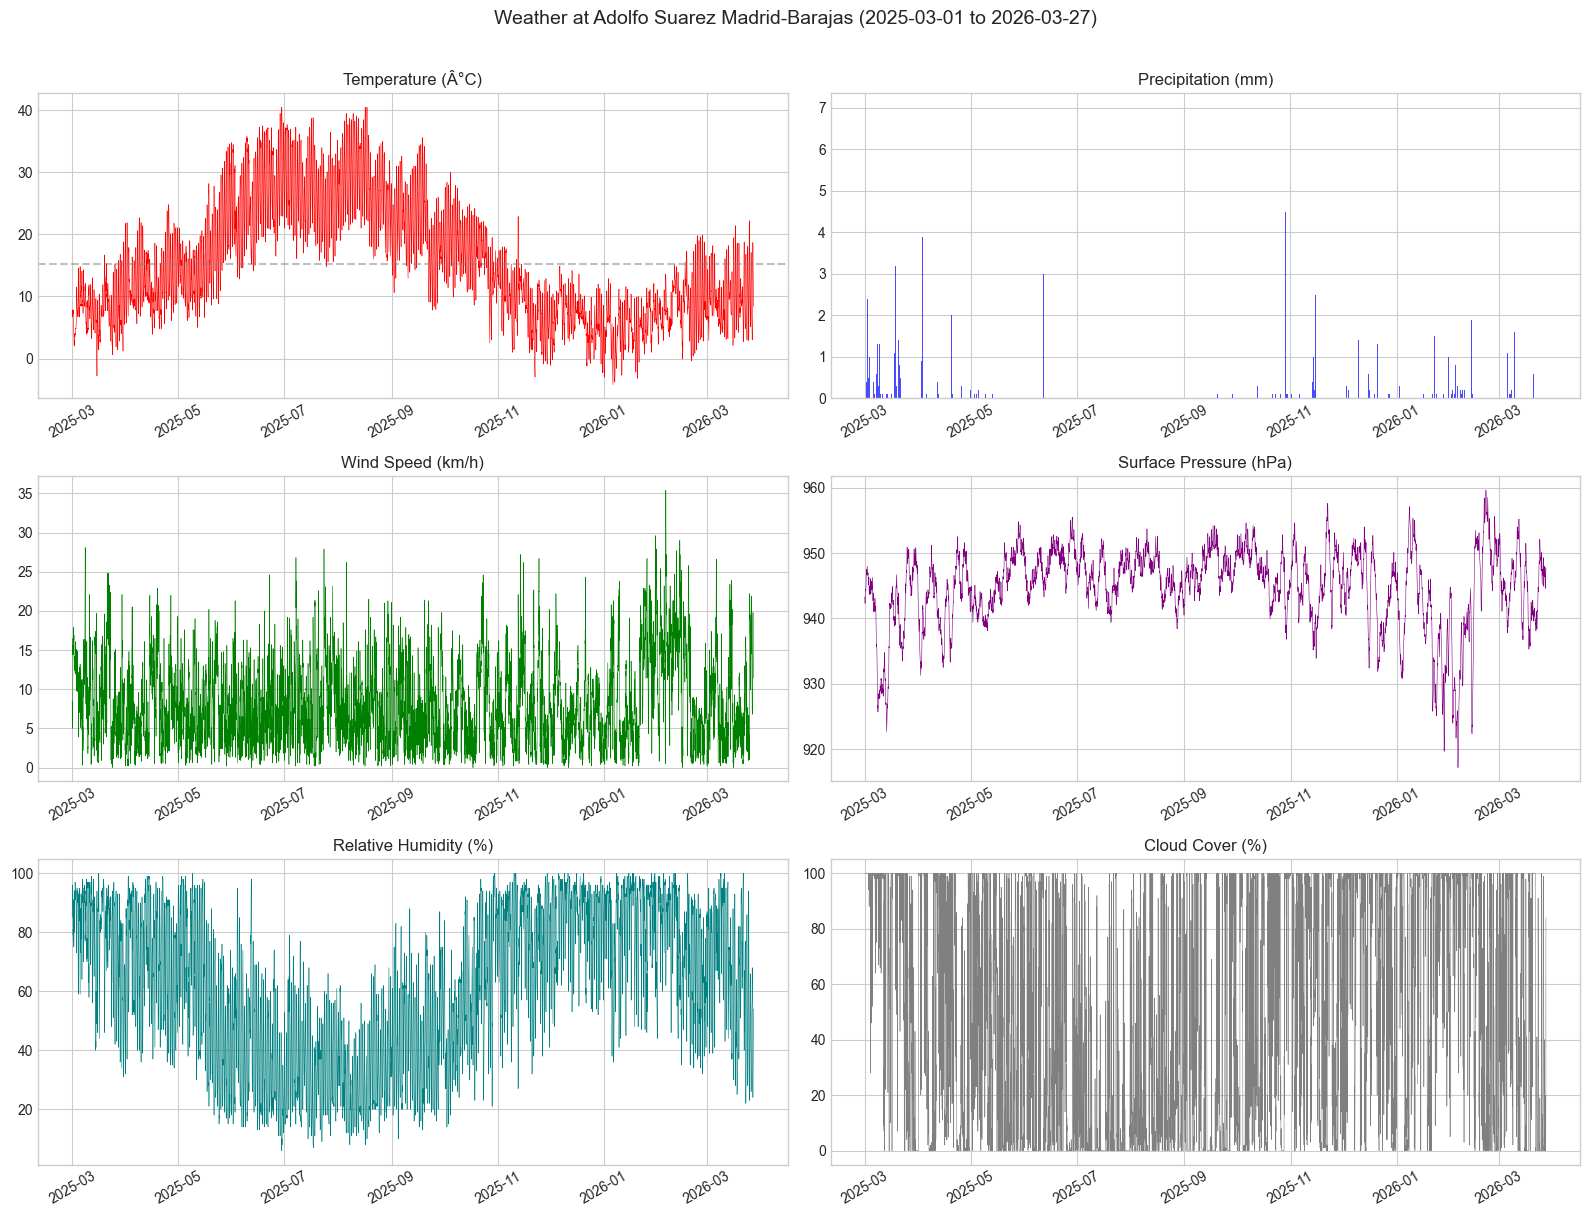

In [ ]:
# Weather overview - 6-panel visualization
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
w = weather.set_index('timestamp')

# Temperature
axes[0, 0].plot(w.index, w['temperature_2m'], linewidth=0.4, color='red')
axes[0, 0].set_title('Temperature (Ãƒâ€šÃ‚Â°C)', fontsize=12)
axes[0, 0].axhline(w['temperature_2m'].mean(), color='gray', linestyle='--', alpha=0.5)

# Precipitation
axes[0, 1].bar(w.index, w['precipitation'], width=0.04, alpha=0.7, color='blue')
axes[0, 1].set_title('Precipitation (mm)', fontsize=12)

# Wind speed
axes[1, 0].plot(w.index, w['wind_speed_10m'], linewidth=0.4, color='green')
axes[1, 0].set_title('Wind Speed (km/h)', fontsize=12)

# Surface pressure
axes[1, 1].plot(w.index, w['surface_pressure'], linewidth=0.4, color='purple')
axes[1, 1].set_title('Surface Pressure (hPa)', fontsize=12)

# Humidity
axes[2, 0].plot(w.index, w['relative_humidity_2m'], linewidth=0.4, color='teal')
axes[2, 0].set_title('Relative Humidity (%)', fontsize=12)

# Cloud cover
axes[2, 1].plot(w.index, w['cloud_cover'], linewidth=0.4, color='gray')
axes[2, 1].set_title('Cloud Cover (%)', fontsize=12)

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(f'Weather at {AIRPORT["name"]} ({DATA_START_DATE} to {DATA_END_DATE})', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'weather_overview_12months.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


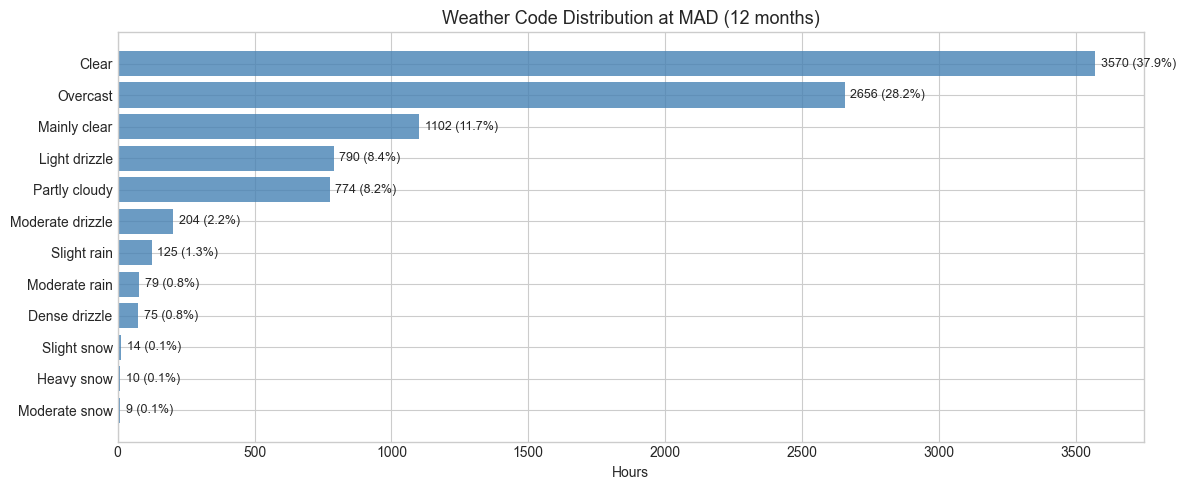

In [ ]:
# Weather code distribution (WMO codes)
# 0=Clear, 1-3=Partly cloudy, 45-48=Fog, 51-55=Drizzle, 61-65=Rain, 71-75=Snow, 80-82=Showers, 95-99=Thunderstorm
weather_code_labels = {
    0: 'Clear', 1: 'Mainly clear', 2: 'Partly cloudy', 3: 'Overcast',
    45: 'Fog', 48: 'Depositing rime fog',
    51: 'Light drizzle', 53: 'Moderate drizzle', 55: 'Dense drizzle',
    61: 'Slight rain', 63: 'Moderate rain', 65: 'Heavy rain',
    71: 'Slight snow', 73: 'Moderate snow', 75: 'Heavy snow',
    80: 'Slight showers', 81: 'Moderate showers', 82: 'Violent showers',
    95: 'Thunderstorm', 96: 'T-storm w/ hail', 99: 'T-storm w/ heavy hail'
}

code_counts = weather['weather_code'].value_counts().head(15)
code_labels = [weather_code_labels.get(c, f'Code {c}') for c in code_counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(range(len(code_counts)), code_counts.values, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(code_counts)))
ax.set_yticklabels(code_labels)
ax.set_xlabel('Hours')
ax.set_title('Weather Code Distribution at MAD (12 months)', fontsize=13)
ax.invert_yaxis()

# Add counts
for bar, val in zip(bars, code_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, f'{val} ({val/len(weather)*100:.1f}%)',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'weather_code_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


In [ ]:
# Monthly weather summary
weather['month'] = weather['timestamp'].dt.month
monthly = weather.groupby('month').agg({
    'temperature_2m': 'mean',
    'precipitation': 'sum',
    'wind_speed_10m': 'mean',
    'relative_humidity_2m': 'mean'
}).round(1)
monthly.columns = ['Avg Temp (Ãƒâ€šÃ‚Â°C)', 'Total Precip (mm)', 'Avg Wind (km/h)', 'Avg Humidity (%)']
print("Monthly Weather Summary:")
print(monthly.to_string())
weather.drop(columns=['month'], inplace=True)

Monthly Weather Summary:
       Avg Temp (Ãƒâ€šÃ‚Â°C)  Total Precip (mm)  Avg Wind (km/h)  Avg Humidity (%)
month                                                                      
1                 4.9              124.4              9.8              81.9
2                 8.8              105.2             11.8              75.3
3                 9.0              322.5              8.9              73.6
4                12.7               99.4              8.1              71.7
5                17.0               76.8              7.4              58.1
6                26.4               24.3              7.1              39.2
7                27.0                5.8              9.1              33.7
8                28.0                1.0              7.4              31.3
9                21.4                5.2              7.5              42.2
10               17.2               31.7              7.6              57.2
11                8.7               63.3              7.

---
## 4. Holiday & Calendar Data

In [ ]:
from src.data.fetch_holidays import fetch_holidays

holidays = fetch_holidays()
print(f"Spanish public holidays in range: {len(holidays)}")
print()
if not holidays.empty:
    for _, row in holidays.iterrows():
        print(f"  {row['date'].strftime('%Y-%m-%d')} ({row['date'].strftime('%A'):>10s})  {row.get('localName', row.get('name', ''))}")

[2026-03-27 19:36:53] src.data.fetch_holidays - INFO - Holidays 2025 cached: C:\Users\Ian\FlightScanner_Emerging\data\raw\holidays\spain_holidays_2025.json
[2026-03-27 19:36:53] src.data.fetch_holidays - INFO - Holidays 2026 cached: C:\Users\Ian\FlightScanner_Emerging\data\raw\holidays\spain_holidays_2026.json
[2026-03-27 19:36:53] src.data.fetch_holidays - INFO - Holidays: 33 holidays in range 2025-03-01 to 2026-03-27
Spanish public holidays in range: 33

  2025-03-01 (  Saturday)  Dia de les Illes Balears
  2025-04-17 (  Thursday)  Jueves Santo
  2025-04-18 (    Friday)  Viernes Santo
  2025-04-21 (    Monday)  Lunes de Pascua
  2025-04-23 ( Wednesday)  DÃƒÂ­a de Castilla y LeÃƒÂ³n
  2025-04-23 ( Wednesday)  San Jorge (DÃƒÂ­a de AragÃƒÂ³n)
  2025-05-01 (  Thursday)  Fiesta del trabajo
  2025-05-02 (    Friday)  Fiesta de la Comunidad de Madrid
  2025-05-17 (  Saturday)  DÃƒÂ­a das Letras Galegas
  2025-05-30 (    Friday)  DÃƒÂ­a de Canarias
  2025-05-31 (  Saturday)  DÃƒÂ­a de la Reg

---
## 5. Airport Metadata

In [ ]:
from src.data.fetch_airport_metadata import fetch_airport_metadata

airport_meta = fetch_airport_metadata()
print("Airport Metadata:")
for col in airport_meta.columns:
    print(f"  {col}: {airport_meta.iloc[0][col]}")

print(f"\nGeospatial analysis bands:")
for band, km in ANALYSIS_BANDS.items():
    print(f"  {band}: {km} km from airport")

[2026-03-27 19:36:53] src.data.fetch_airport_metadata - INFO - Airport metadata cached: C:\Users\Ian\FlightScanner_Emerging\data\raw\ourairports\airport_reference.parquet
Airport Metadata:
  ident: LEMD
  type: large_airport
  name: Adolfo SuÃƒÂ¡rez MadridÃ¢â‚¬â€œBarajas Airport
  latitude_deg: 40.493407
  longitude_deg: -3.572249
  elevation_ft: 1998.0
  continent: EU
  iso_country: ES
  iso_region: ES-MD
  municipality: Madrid
  iata_code: MAD

Geospatial analysis bands:
  inner: 15 km from airport
  middle: 40 km from airport
  outer: 80 km from airport


---
## 6. Live Aircraft Positions (OpenSky State Vectors + FlightRadar24)

In [ ]:
# OpenSky state vectors - live aircraft in bounding box
from src.data.fetch_opensky import fetch_state_vectors

state_vectors = fetch_state_vectors()
if state_vectors is not None and not state_vectors.empty:
    print(f"OpenSky state vectors: {len(state_vectors)} aircraft near {AIRPORT_ICAO}")
    print(state_vectors[['icao24', 'callsign', 'latitude', 'longitude', 'baro_altitude', 'velocity', 'on_ground']].head(15).to_string(index=False))
else:
    print("No state vectors collected")

[2026-03-27 19:36:53] src.utils.io_utils - INFO - Saved 34 rows to C:\Users\Ian\FlightScanner_Emerging\data\raw\opensky\state_vectors_20260327_183653.parquet (state vectors snapshot (34 aircraft))
[2026-03-27 19:36:53] src.data.fetch_opensky - INFO - State vectors: 34 aircraft near LEMD
OpenSky state vectors: 34 aircraft near LEMD
icao24 callsign  latitude  longitude  baro_altitude  velocity  on_ground
39de4e TVF47ZR    40.8192    -2.8143        5143.50    175.98      False
346689 IBB533Y    40.4627    -3.5535         586.74     76.25      False
484ee4 KLM33K     40.4632    -3.5256         632.46     82.52      False
02007d RAM789H    40.0210    -2.9636       11277.60    240.73      False
406ae3 BAW467     40.5398    -3.5750        1234.44     69.45      False
343385 IBS1576    40.2154    -3.3870        1356.36    107.71      False
344648 IBE07RR    40.4616    -3.5524         586.74     63.49      False
48c232 RYR96SV    40.4646    -3.5673            NaN      2.57       True
342189 IBE

In [ ]:
# FlightRadar24 live snapshot - flight positions with more detail
from src.data.fetch_flightradar import fetch_live_snapshot

snapshot = fetch_live_snapshot()
if snapshot:
    print(f"FR24 live snapshot: {snapshot['flight_count']} flights")
    print(f"Timestamp: {snapshot['timestamp_utc']}")
    snap_df = pd.DataFrame(snapshot['flights'])
    if not snap_df.empty:
        print(snap_df[['callsign', 'latitude', 'longitude', 'altitude', 'ground_speed']].head(10).to_string(index=False))
else:
    print("FR24 live snapshot not available (optional - project continues)")

[2026-03-27 19:36:53] src.data.fetch_flightradar - INFO - Live snapshot: 45 flights near airport at 20260327_183653
FR24 live snapshot: 45 flights
Timestamp: 2026-03-27T18:36:53.777815+00:00
callsign  latitude  longitude  altitude  ground_speed
 RYR38XY   40.7509    -4.2266     19800           383
 AEA13QD   40.6385    -3.7999     10975           305
 RYR45PR   40.3944    -3.7604     16225           386
 TVS482F   40.9649    -3.7601     38000           407
 ARL385R   41.0287    -3.7505     24025           400
 AEA5034   40.0709    -3.5929      8900           239
 IBE05DM   40.4965    -3.5887         0             8
 LGL37LM   40.4905    -3.5885         0             6
 IBE07RR   40.4872    -3.5882         0            17
  FAUNA5   40.4937    -3.5827         0            24


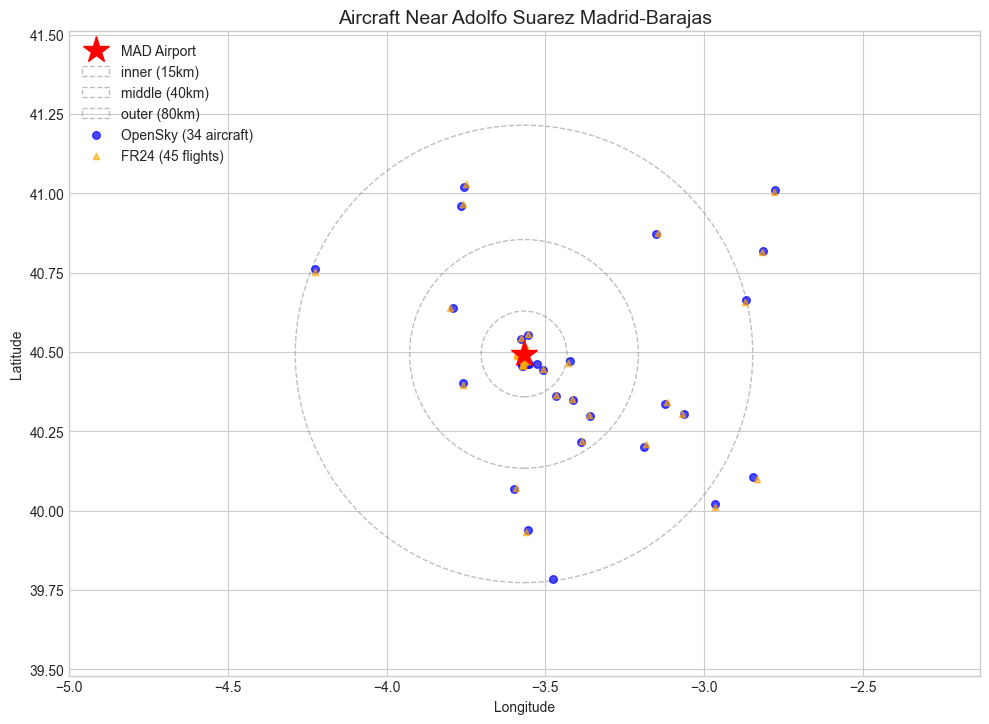

In [ ]:
# Quick spatial plot of aircraft positions
fig, ax = plt.subplots(figsize=(10, 10))

# Airport location
ax.plot(AIRPORT_LON, AIRPORT_LAT, 'r*', markersize=20, label=f'{AIRPORT_IATA} Airport', zorder=5)

# Analysis bands (approximate circles)
for band, km in ANALYSIS_BANDS.items():
    deg = km / 111.0  # rough km-to-degree conversion
    circle = plt.Circle((AIRPORT_LON, AIRPORT_LAT), deg, fill=False, linestyle='--', 
                        color='gray', alpha=0.5, label=f'{band} ({km}km)')
    ax.add_patch(circle)

# Plot state vectors
if state_vectors is not None and not state_vectors.empty:
    sv = state_vectors.dropna(subset=['latitude', 'longitude'])
    ax.scatter(sv['longitude'], sv['latitude'], c='blue', s=30, alpha=0.7, label=f'OpenSky ({len(sv)} aircraft)')

# Plot FR24 snapshot
if snapshot and snapshot['flights']:
    snap_df = pd.DataFrame(snapshot['flights']).dropna(subset=['latitude', 'longitude'])
    ax.scatter(snap_df['longitude'], snap_df['latitude'], c='orange', s=20, alpha=0.6, marker='^',
              label=f'FR24 ({len(snap_df)} flights)')

ax.set_xlim(BOUNDING_BOX['west'] - 0.5, BOUNDING_BOX['east'] + 0.5)
ax.set_ylim(BOUNDING_BOX['south'] - 0.3, BOUNDING_BOX['north'] + 0.3)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Aircraft Near {AIRPORT["name"]}', fontsize=14)
ax.legend(loc='upper left')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'aircraft_positions_snapshot.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


---
## 7. Data Validation

In [ ]:
from src.data.validate_raw_data import run_all_validations

report = run_all_validations()

print("\n" + "="*60)
print("DATA VALIDATION REPORT")
print("="*60)
for source, results in report.items():
    issues = results.get('issues', [])
    status = 'PASS' if not issues else f'WARN ({len(issues)} issues)'
    print(f"\n[{source.upper()}] {status}")
    for key, value in results.items():
        if key != 'issues':
            print(f"  {key}: {value}")
    if issues:
        for issue in issues:
            print(f"  ÃƒÂ¢Ã…Â¡Ã‚Â  {issue}")

[2026-03-27 19:36:54] src.data.validate_raw_data - INFO - Running data validation...
[2026-03-27 19:36:54] src.data.validate_raw_data - INFO - Validation complete. 2 issue(s) found.
[2026-03-27 19:36:54] src.data.validate_raw_data - WARNING -   [opensky] Missing combined arrivals file
[2026-03-27 19:36:54] src.data.validate_raw_data - WARNING -   [opensky] Missing combined departures file
[2026-03-27 19:36:54] src.data.validate_raw_data - INFO -   [weather] OK
[2026-03-27 19:36:54] src.data.validate_raw_data - INFO -   [holidays] OK
[2026-03-27 19:36:54] src.data.validate_raw_data - INFO -   [airport_metadata] OK

DATA VALIDATION REPORT

[OPENSKY] WARN (2 issues)
  source: opensky
  airport: LEMD
  ÃƒÂ¢Ã…Â¡Ã‚Â  Missing combined arrivals file
  ÃƒÂ¢Ã…Â¡Ã‚Â  Missing combined departures file

[WEATHER] PASS
  source: weather
  rows: 9408
  columns: ['timestamp', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'weather_code', 'surface_pressure', 'wind_speed_10m', 'wind_d

---
## 8. Data Summary & Quality Assessment

In [ ]:
# Comprehensive data summary
print("="*60)
print("DATA FOUNDATION SUMMARY")
print("="*60)

print(f"\n--- Flight Data (FlightRadar24 Board) ---")
print(f"  Arrivals: {len(arrivals)} flights")
print(f"  Departures: {len(departures)} flights")
print(f"  Time window: {arrivals['sched_arrival_dt'].min()} to {arrivals['sched_arrival_dt'].max()}")
print(f"  Unique origins: {arrivals['origin_iata'].nunique()} airports")
print(f"  Unique destinations: {departures['dest_iata'].nunique()} airports")
print(f"  Hourly movements: {len(hourly_movements)} hours")
print(f"  Avg movements/hour: {hourly_movements['movements'].mean():.1f}")

print(f"\n--- Weather Data (Open-Meteo) ---")
print(f"  Hours: {len(weather)}")
print(f"  Range: {weather['timestamp'].min()} to {weather['timestamp'].max()}")
print(f"  Variables: {len(weather.columns) - 1}")
print(f"  Nulls: {weather.isnull().sum().sum()} total")

print(f"\n--- Holidays ---")
print(f"  Spanish holidays: {len(holidays)}")

print(f"\n--- Geospatial ---")
sv_count = len(state_vectors) if state_vectors is not None and not state_vectors.empty else 0
snap_count = snapshot['flight_count'] if snapshot else 0
print(f"  OpenSky state vectors: {sv_count} aircraft")
print(f"  FR24 live snapshot: {snap_count} flights")

print(f"\n--- Airport ---")
print(f"  {AIRPORT['name']} ({AIRPORT_ICAO}/{AIRPORT_IATA})")
print(f"  Coordinates: ({AIRPORT_LAT}, {AIRPORT_LON})")

DATA FOUNDATION SUMMARY

--- Flight Data (FlightRadar24 Board) ---
  Arrivals: 1260 flights
  Departures: 1246 flights
  Time window: 2026-03-27 18:20:00+00:00 to 2026-03-29 06:15:00+00:00
  Unique origins: 175 airports
  Unique destinations: 167 airports
  Hourly movements: 37 hours
  Avg movements/hour: 67.7

--- Weather Data (Open-Meteo) ---
  Hours: 9408
  Range: 2025-03-01 00:00:00+00:00 to 2026-03-27 23:00:00+00:00
  Variables: 10
  Nulls: 0 total

--- Holidays ---
  Spanish holidays: 33

--- Geospatial ---
  OpenSky state vectors: 34 aircraft
  FR24 live snapshot: 45 flights

--- Airport ---
  Adolfo Suarez Madrid-Barajas (LEMD/MAD)
  Coordinates: (40.4936, -3.5668)


In [ ]:
# Save the hourly movements as an intermediate file for C2
from src.utils.io_utils import save_parquet

movements_path = Path(get_path('intermediate')) / 'hourly_movements.parquet'
hourly_movements_save = hourly_movements.reset_index()
hourly_movements_save['airport_icao'] = AIRPORT_ICAO
save_parquet(hourly_movements_save, movements_path, 'hourly movements from FR24 board')

print(f"\nSaved hourly movements to: {movements_path}")
print(f"Shape: {hourly_movements_save.shape}")
print(f"Columns: {list(hourly_movements_save.columns)}")

[2026-03-27 19:36:54] src.utils.io_utils - INFO - Saved 37 rows to C:\Users\Ian\FlightScanner_Emerging\data\intermediate\hourly_movements.parquet (hourly movements from FR24 board)

Saved hourly movements to: C:\Users\Ian\FlightScanner_Emerging\data\intermediate\hourly_movements.parquet
Shape: (37, 5)
Columns: ['timestamp', 'arrivals', 'departures', 'movements', 'airport_icao']


---
## 9. ACPS Target Definition (Preview)

The **Airport Congestion Pressure Score** will be computed in the feature engineering notebook. Here we preview the concept.

Formula:
- `baseline_hour_dow = median(movements for same hour-of-day and day-of-week)`
- `pressure_ratio = movements / max(1, baseline)`
- `ACPS = 0.6 * standardized(movements) + 0.4 * standardized(pressure_ratio)`

Classification thresholds:
- **Low:** below 60th percentile
- **Medium:** 60th to 85th percentile  
- **High:** above 85th percentile

Preliminary congestion thresholds (movements):
  Low: 0 to 66
  Medium: 66 to 83
  High: above 83

Distribution:
congestion_preview
Low       24
Medium     7
High       6
Name: count, dtype: int64


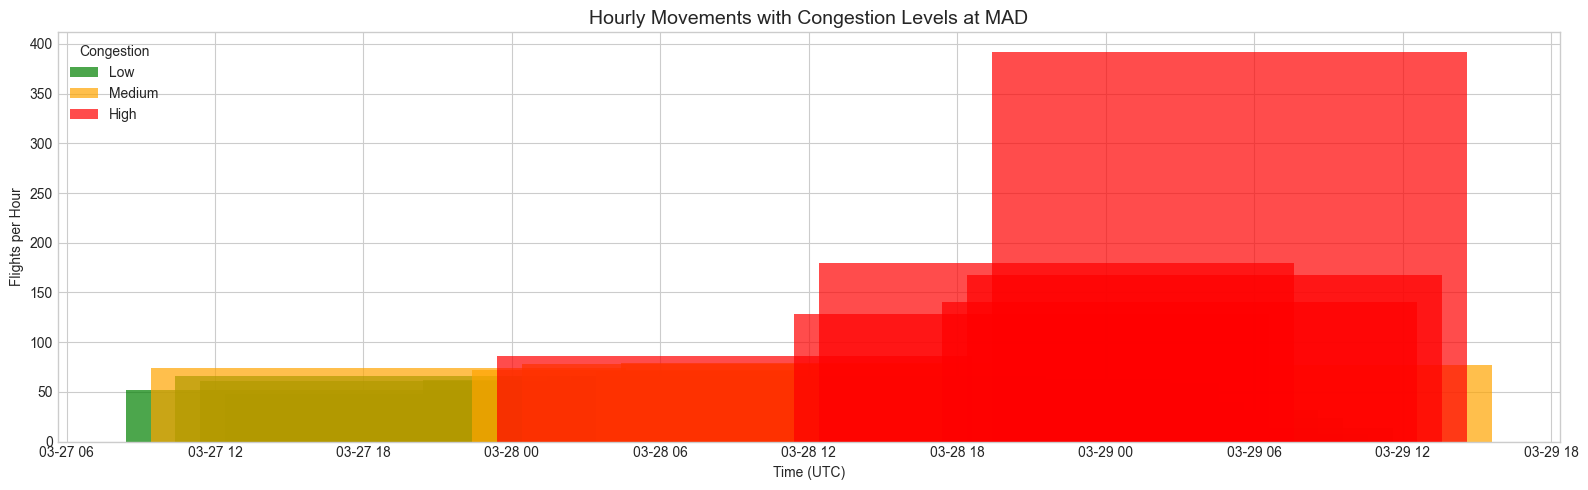

In [ ]:
# Preview: simple congestion levels based on movement counts
p60 = hourly_movements['movements'].quantile(0.60)
p85 = hourly_movements['movements'].quantile(0.85)

hourly_movements['congestion_preview'] = pd.cut(
    hourly_movements['movements'],
    bins=[-1, p60, p85, float('inf')],
    labels=['Low', 'Medium', 'High']
)

print(f"Preliminary congestion thresholds (movements):")
print(f"  Low: 0 to {p60:.0f}")
print(f"  Medium: {p60:.0f} to {p85:.0f}")
print(f"  High: above {p85:.0f}")
print(f"\nDistribution:")
print(hourly_movements['congestion_preview'].value_counts().sort_index())

# Visualize
colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}
fig, ax = plt.subplots(figsize=(16, 5))
for level, color in colors.items():
    mask = hourly_movements['congestion_preview'] == level
    subset = hourly_movements[mask]
    ax.bar(subset.index, subset['movements'], color=color, alpha=0.7, label=level)

ax.set_title(f'Hourly Movements with Congestion Levels at {AIRPORT_IATA}', fontsize=14)
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Flights per Hour')
ax.legend(title='Congestion')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'congestion_preview.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


---
## 10. Limitations & Next Steps

### Data Limitations
- Flight data covers ~36 hours from the FlightRadar24 airport board (not 12 months)
- OpenSky historical flights endpoint requires research-tier access (returned `403: You cannot access historical flights`)
- The FR24 unofficial wrapper provides real scheduled/actual flight data but only for the current board window
- With full OpenSky Trino access or periodic FR24 collection, the dataset could be extended significantly

### What's Available for Modeling
- **36 hours** of real hourly flight movements (sufficient to demonstrate pipeline and daily patterns)
- **12 months** of hourly weather data (full seasonal coverage)
- **33 holidays** for calendar feature engineering
- **Live geospatial snapshots** for spatial analysis

### Next Steps
- **Notebook 04:** Data cleaning, integration, and feature engineering
- **Notebook 05:** EDA - temporal patterns and correlations
- **Notebook 06:** Geospatial analysis with maps
- **Notebook 07:** Feature engineering (lags, rolling, calendar, weather)
- **Notebook 08:** Baseline models and SARIMAX

---
*TODO: H2 to validate flight counts against AENA public statistics*  
*TODO: H2 to check if regional Madrid holidays need manual addition*  
*TODO: H1 to add airport context (terminals, runways, hub role)*

In [ ]:
print("Notebook 01 complete. All raw data collected and validated.")
print(f"\nFiles created:")
for f in sorted(Path(get_path('raw')).rglob('*')):
    if f.is_file() and f.name != '.gitkeep':
        size = f.stat().st_size
        unit = 'KB' if size > 1024 else 'B'
        val = size / 1024 if size > 1024 else size
        print(f"  {f.relative_to(Path(get_path('raw')))} ({val:.1f} {unit})")

Notebook 01 complete. All raw data collected and validated.

Files created:
  flightradar\fr24_arrivals_board.parquet (34.4 KB)
  flightradar\fr24_departures_board.parquet (33.0 KB)
  flightradar\live_snapshots\snapshot_20260327_182101.json (14.9 KB)
  flightradar\live_snapshots\snapshot_20260327_183653.json (13.8 KB)
  holidays\spain_holidays_2025.json (9.4 KB)
  holidays\spain_holidays_2026.json (9.4 KB)
  open_meteo\weather_hourly_LEMD.parquet (170.4 KB)
  opensky\state_vectors_20260327_181916.parquet (12.6 KB)
  opensky\state_vectors_20260327_183653.parquet (13.1 KB)
  ourairports\airport_reference.parquet (6.6 KB)
  ourairports\airports.csv (12279.5 KB)


---
---
# Part 2: Feature Engineering & Forecasting

##  Feature Engineering, EDA & Forecasting Models

## Purpose
This notebook is the complete C2 pipeline:
1. Loads raw data from Notebook 01
2. Computes the ACPS (Airport Congestion Pressure Score) target
3. Engineers calendar, weather, lag, and rolling features
4. Assembles the model-ready table with train/valid/test splits
5. Explores feature patterns with EDA
6. Trains baseline models and SARIMAX
7. Compares all models and saves outputs for C3

## Prerequisites
- Notebook 01 must have been run (raw data collected)

## Outputs
- `data/intermediate/hourly_weather.parquet`, `hourly_calendar_features.parquet`
- `data/processed/model_table_hourly.parquet`, `train.parquet`, `valid.parquet`, `test.parquet`
- `outputs/tables/baseline_comparison.csv`
- `outputs/figures/` - EDA and model comparison figures

In [ ]:
# === Setup ===
import sys, warnings
from pathlib import Path
from datetime import timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import AIRPORT_ICAO, AIRPORT_IATA, AIRPORT_TZ, MODELING, DATA_START_DATE, DATA_END_DATE, get_path

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

FIGURES_DIR = Path(get_path('figures'))
TABLES_DIR = Path(get_path('tables'))
INTERMEDIATE_DIR = Path(get_path('intermediate'))
PROCESSED_DIR = Path(get_path('processed'))

print(f"Modeling config: {MODELING['target']}")
print(f"Lag hours: {MODELING['lag_hours']}")
print(f"Split ratios: {MODELING['split']}")

Modeling config: {'acps_movement_weight': 0.6, 'acps_pressure_weight': 0.4, 'low_threshold': 60, 'high_threshold': 85}
Lag hours: [1, 2, 3, 6, 12, 24, 48, 168]
Split ratios: {'train': 0.7, 'validation': 0.15, 'test': 0.15}


---
## 1. Load Raw Data from Notebook 01

In [ ]:
# Load all data sources
movements = pd.read_parquet(INTERMEDIATE_DIR / 'hourly_movements.parquet')
movements['timestamp'] = pd.to_datetime(movements['timestamp'], utc=True)
movements = movements.sort_values('timestamp').reset_index(drop=True)
print(f"Movements: {len(movements)} hours, range: {movements['timestamp'].min()} to {movements['timestamp'].max()}")
print(movements.describe().round(1))

weather_raw = pd.read_parquet(Path(get_path('raw_weather')) / f'weather_hourly_{AIRPORT_ICAO}.parquet')
weather_raw['timestamp'] = pd.to_datetime(weather_raw['timestamp'], utc=True)
print(f"\nWeather: {len(weather_raw)} hours")

from src.data.fetch_holidays import fetch_holidays
holidays_df = fetch_holidays()
holiday_dates = set(holidays_df['date'].dt.date) if not holidays_df.empty else set()
print(f"Holidays: {len(holiday_dates)} dates")

Movements: 37 hours, range: 2026-03-27 18:00:00+00:00 to 2026-03-29 06:00:00+00:00
       arrivals  departures  movements
count      37.0        37.0       37.0
mean       34.1        33.7       67.7
std        32.6        55.4       69.1
min         1.0         0.0        3.0
25%        14.0         6.0       32.0
50%        28.0        25.0       61.0
75%        42.0        37.0       74.0
max       168.0       329.0      392.0

Weather: 9408 hours
[2026-03-27 19:57:08] src.data.fetch_holidays - INFO - Holidays 2025 cached: C:\Users\Ian\FlightScanner_Emerging\data\raw\holidays\spain_holidays_2025.json
[2026-03-27 19:57:08] src.data.fetch_holidays - INFO - Holidays 2026 cached: C:\Users\Ian\FlightScanner_Emerging\data\raw\holidays\spain_holidays_2026.json
[2026-03-27 19:57:08] src.data.fetch_holidays - INFO - Holidays: 33 holidays in range 2025-03-01 to 2026-03-27
Holidays: 30 dates


---
## 2. ACPS Target Construction

**Airport Congestion Pressure Score:**
- `baseline_hour_dow = median(movements for same hour+dow)`
- `pressure_ratio = movements / max(1, baseline)`
- `ACPS = 0.6 * standardized(movements) + 0.4 * standardized(pressure_ratio)`

Classification: Low (<60th pctl) / Medium (60-85th) / High (>85th)

In [ ]:
# Compute ACPS target
df = movements.copy()
df['hour'] = df['timestamp'].dt.hour
df['dow'] = df['timestamp'].dt.dayofweek

baselines = df.groupby(['hour', 'dow'])['movements'].transform('median')
df['baseline_hour_dow'] = baselines
df['pressure_ratio'] = df['movements'] / df['baseline_hour_dow'].clip(lower=1)

def safe_standardize(series):
    std = series.std()
    return (series - series.mean()) / std if (std > 0 and not pd.isna(std)) else series - series.mean()

w_mov = MODELING['target']['acps_movement_weight']
w_pres = MODELING['target']['acps_pressure_weight']
df['acps'] = w_mov * safe_standardize(df['movements']) + w_pres * safe_standardize(df['pressure_ratio'])

p60 = df['acps'].quantile(MODELING['target']['low_threshold'] / 100)
p85 = df['acps'].quantile(MODELING['target']['high_threshold'] / 100)
df['congestion_class'] = pd.cut(df['acps'], bins=[-np.inf, p60, p85, np.inf], labels=['Low', 'Medium', 'High'])
df['congestion_binary'] = (df['acps'] >= p85).astype(int)

print(f"ACPS: {len(df)} hours | Thresholds: Low<{p60:.3f}, High>={p85:.3f}")
print(df['congestion_class'].value_counts().sort_index())
print(f"\n{df['acps'].describe().round(3)}")

ACPS: 37 hours | Thresholds: Low<-0.015, High>=0.134
congestion_class
Low       24
Medium     7
High       6
Name: count, dtype: int64

count    37.000
mean      0.000
std       0.600
min      -0.562
25%      -0.310
50%      -0.058
75%       0.054
max       2.814
Name: acps, dtype: float64


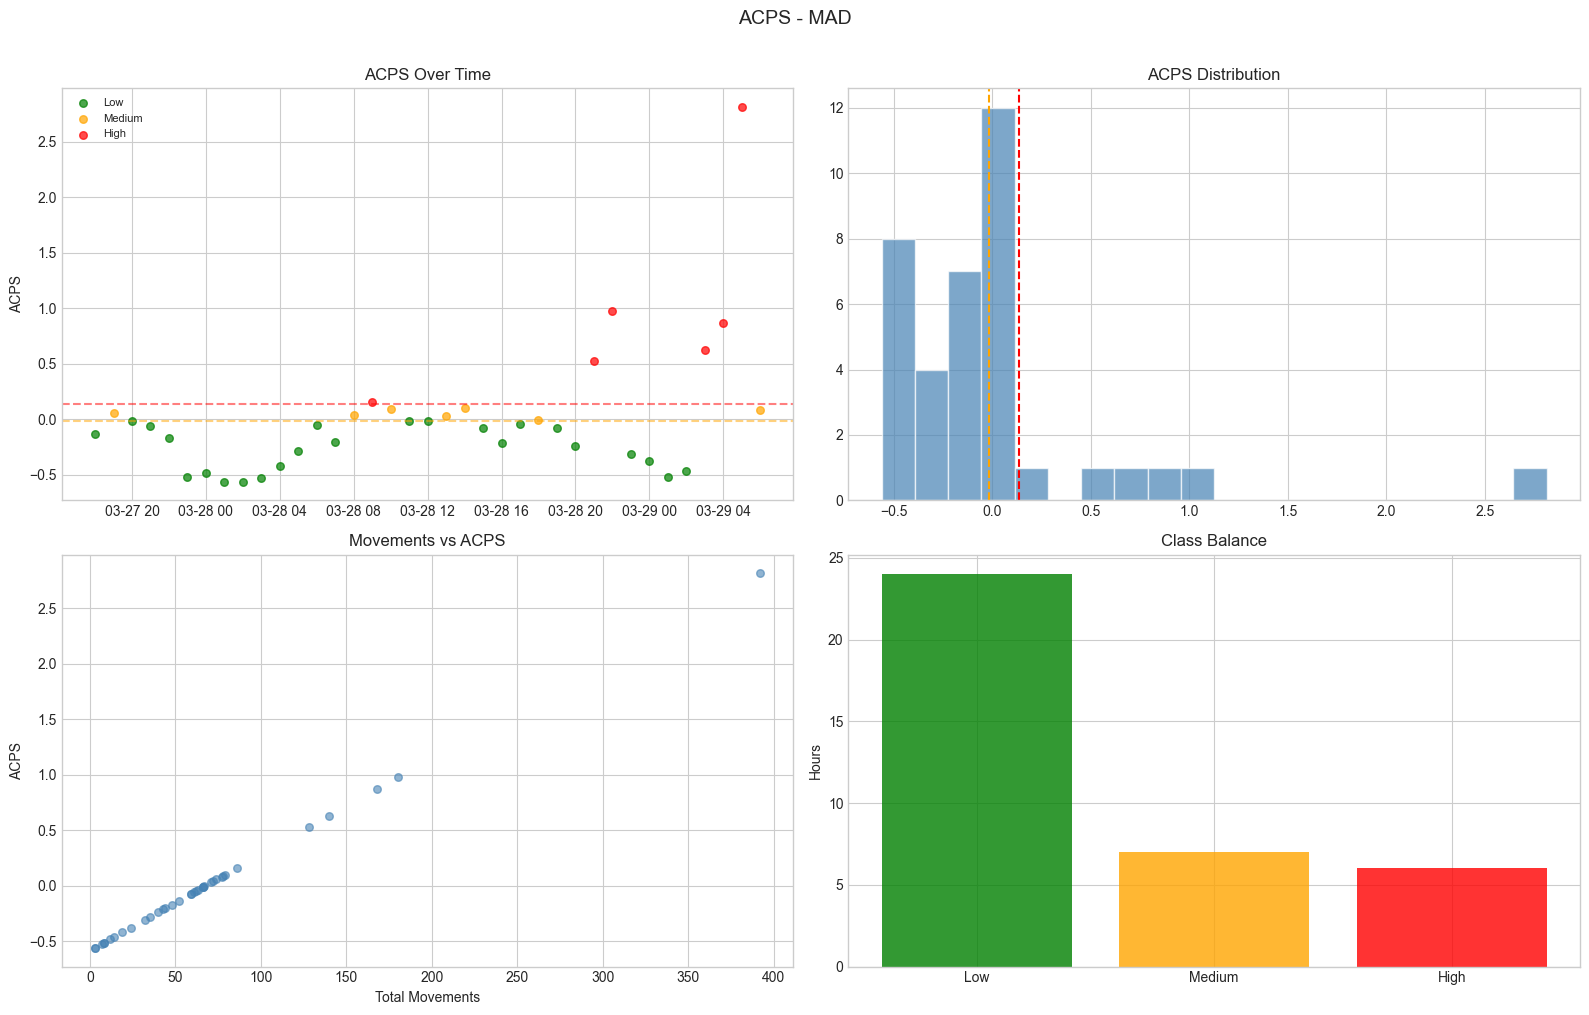

In [ ]:
# Visualize ACPS
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors_map = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}

for cls, color in colors_map.items():
    mask = df['congestion_class'] == cls
    axes[0,0].scatter(df.loc[mask, 'timestamp'], df.loc[mask, 'acps'], c=color, s=30, alpha=0.7, label=cls)
axes[0,0].axhline(p60, color='orange', ls='--', alpha=0.5); axes[0,0].axhline(p85, color='red', ls='--', alpha=0.5)
axes[0,0].set_title('ACPS Over Time'); axes[0,0].legend(fontsize=8); axes[0,0].set_ylabel('ACPS')

axes[0,1].hist(df['acps'], bins=20, color='steelblue', alpha=0.7, edgecolor='white')
axes[0,1].axvline(p60, color='orange', ls='--'); axes[0,1].axvline(p85, color='red', ls='--')
axes[0,1].set_title('ACPS Distribution')

axes[1,0].scatter(df['movements'], df['acps'], c='steelblue', alpha=0.6, s=30)
axes[1,0].set_xlabel('Total Movements'); axes[1,0].set_ylabel('ACPS'); axes[1,0].set_title('Movements vs ACPS')

cc = df['congestion_class'].value_counts().sort_index()
axes[1,1].bar(cc.index, cc.values, color=[colors_map[c] for c in cc.index], alpha=0.8)
axes[1,1].set_title('Class Balance'); axes[1,1].set_ylabel('Hours')

plt.suptitle(f'ACPS - {AIRPORT_IATA}', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'acps_overview.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

---
## 3. Calendar Feature Engineering

In [ ]:
# Calendar features
cal = pd.DataFrame({'timestamp': df['timestamp']})
cal['hour'] = cal['timestamp'].dt.hour
cal['dow'] = cal['timestamp'].dt.dayofweek
cal['is_weekend'] = cal['dow'].isin([5, 6]).astype(int)
cal['month'] = cal['timestamp'].dt.month
cal['quarter'] = cal['timestamp'].dt.quarter

cal['date'] = cal['timestamp'].dt.date
cal['is_holiday'] = cal['date'].isin(holiday_dates).astype(int)
pre_hol = {d - timedelta(days=1) for d in holiday_dates}
post_hol = {d + timedelta(days=1) for d in holiday_dates}
cal['is_pre_holiday'] = cal['date'].isin(pre_hol).astype(int)
cal['is_post_holiday'] = cal['date'].isin(post_hol).astype(int)

def is_bridge(d, hols):
    if d.weekday() >= 5 or d in hols: return False
    p, n = d - timedelta(days=1), d + timedelta(days=1)
    return (p.weekday() >= 5 or p in hols) and (n.weekday() >= 5 or n in hols)

cal['is_bridge_day'] = cal['date'].apply(lambda d: int(is_bridge(d, holiday_dates)))
cal.drop(columns=['date'], inplace=True)

cal['hour_sin'] = np.sin(2 * np.pi * cal['hour'] / 24)
cal['hour_cos'] = np.cos(2 * np.pi * cal['hour'] / 24)
cal['dow_sin'] = np.sin(2 * np.pi * cal['dow'] / 7)
cal['dow_cos'] = np.cos(2 * np.pi * cal['dow'] / 7)

cal.to_parquet(INTERMEDIATE_DIR / 'hourly_calendar_features.parquet', index=False)
print(f"Calendar: {len(cal)} rows, {len(cal.columns)} cols: {list(cal.columns)}")
print(f"Holidays: {cal['is_holiday'].sum()}, Weekends: {cal['is_weekend'].sum()}")

Calendar: 37 rows, 14 cols: ['timestamp', 'hour', 'dow', 'is_weekend', 'month', 'quarter', 'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'is_bridge_day', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
Holidays: 0, Weekends: 31


---
## 4. Weather Feature Engineering

In [ ]:
# Align weather to flight window with forward-fill for future hours
t_min, t_max = df['timestamp'].min(), df['timestamp'].max()
weather = weather_raw[(weather_raw['timestamp'] >= t_min) & (weather_raw['timestamp'] <= t_max)].copy()
print(f"Direct weather matches: {len(weather)} hours")

all_hours = pd.DataFrame({'timestamp': df['timestamp']})
weather = all_hours.merge(weather, on='timestamp', how='left').ffill().bfill()
print(f"After forward-fill: {len(weather)} hours, NaN remaining: {weather.isnull().sum().sum()}")

weather['wind_dir_sin'] = np.sin(np.deg2rad(weather['wind_direction_10m']))
weather['wind_dir_cos'] = np.cos(np.deg2rad(weather['wind_direction_10m']))
weather['is_severe_weather'] = (weather['weather_code'] >= 65).astype(int)
weather['is_raining'] = (weather['rain'] > 0).astype(int)
weather['wind_bucket'] = pd.cut(weather['wind_speed_10m'], bins=[-1,10,30,50,200], labels=['calm','moderate','strong','severe'])

weather.to_parquet(INTERMEDIATE_DIR / 'hourly_weather.parquet', index=False)
print(f"\nWeather features: {len(weather.columns)} cols | Severe: {weather['is_severe_weather'].sum()} | Rain: {weather['is_raining'].sum()}")
print(weather['wind_bucket'].value_counts())

Direct weather matches: 6 hours
After forward-fill: 37 hours, NaN remaining: 0

Weather features: 16 cols | Severe: 0 | Rain: 0
wind_bucket
moderate    37
calm         0
strong       0
severe       0
Name: count, dtype: int64


---
## 5. Lag & Rolling Features

In [ ]:
# Lag features - only use lags practical for our data size
available_lags = [h for h in MODELING['lag_hours'] if h < len(df) * 0.5]
skipped_lags = [h for h in MODELING['lag_hours'] if h >= len(df) * 0.5]
print(f"Using lags: {available_lags}")
if skipped_lags:
    print(f"Skipped (data too short): {skipped_lags}")

for h in available_lags:
    df[f'acps_lag_{h}h'] = df['acps'].shift(h)
    df[f'movements_lag_{h}h'] = df['movements'].shift(h)

for w in MODELING['rolling_windows']['mean']:
    if w < len(df) * 0.5:
        df[f'acps_rmean_{w}h'] = df['acps'].rolling(w, min_periods=1).mean()
        df[f'movements_rmean_{w}h'] = df['movements'].rolling(w, min_periods=1).mean()

for w in MODELING['rolling_windows']['std']:
    if w < len(df) * 0.5:
        df[f'acps_rstd_{w}h'] = df['acps'].rolling(w, min_periods=2).std()

df['arr_dep_imbalance'] = (df['arrivals'] - df['departures']) / df['movements'].clip(lower=1)

lag_cols = [c for c in df.columns if 'lag_' in c or 'rmean_' in c or 'rstd_' in c]
print(f"\nCreated {len(lag_cols)} lag/rolling features: {lag_cols}")

Using lags: [1, 2, 3, 6, 12]
Skipped (data too short): [24, 48, 168]

Created 14 lag/rolling features: ['acps_lag_1h', 'movements_lag_1h', 'acps_lag_2h', 'movements_lag_2h', 'acps_lag_3h', 'movements_lag_3h', 'acps_lag_6h', 'movements_lag_6h', 'acps_lag_12h', 'movements_lag_12h', 'acps_rmean_3h', 'movements_rmean_3h', 'acps_rmean_6h', 'movements_rmean_6h']


---
## 6. Model Table Assembly

In [ ]:
# Merge all features
wcols = [c for c in ['timestamp','temperature_2m','precipitation','wind_speed_10m','wind_dir_sin',
    'wind_dir_cos','surface_pressure','relative_humidity_2m','weather_code','wind_gusts_10m',
    'cloud_cover','is_severe_weather','is_raining'] if c in weather.columns]

model_table = df.merge(cal, on='timestamp', how='left', suffixes=('','_cal')).merge(weather[wcols], on='timestamp', how='left')

rows_before = len(model_table)
model_table = model_table.dropna().reset_index(drop=True)
print(f"Model table: {len(model_table)} rows ({rows_before - len(model_table)} dropped from lag NaN), {len(model_table.columns)} columns")
print(f"\nFeature groups:")
print(f"  Target: acps, congestion_class, congestion_binary")
print(f"  Movement: arrivals, departures, movements, arr_dep_imbalance")
print(f"  Calendar: {[c for c in cal.columns if c != 'timestamp']}")
print(f"  Weather: temp, precip, wind, pressure, humidity, flags")
print(f"  Lags/Rolling: {lag_cols}")

model_table.to_parquet(PROCESSED_DIR / 'model_table_hourly.parquet', index=False)
model_table.head()

Model table: 25 rows (12 dropped from lag NaN), 52 columns

Feature groups:
  Target: acps, congestion_class, congestion_binary
  Movement: arrivals, departures, movements, arr_dep_imbalance
  Calendar: ['hour', 'dow', 'is_weekend', 'month', 'quarter', 'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'is_bridge_day', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
  Weather: temp, precip, wind, pressure, humidity, flags
  Lags/Rolling: ['acps_lag_1h', 'movements_lag_1h', 'acps_lag_2h', 'movements_lag_2h', 'acps_lag_3h', 'movements_lag_3h', 'acps_lag_6h', 'movements_lag_6h', 'acps_lag_12h', 'movements_lag_12h', 'acps_rmean_3h', 'movements_rmean_3h', 'acps_rmean_6h', 'movements_rmean_6h']


,timestamp,arrivals,departures,movements,airport_icao,hour,dow,baseline_hour_dow,pressure_ratio,acps,congestion_class,congestion_binary,acps_lag_1h,movements_lag_1h,acps_lag_2h,movements_lag_2h,acps_lag_3h,movements_lag_3h,acps_lag_6h,movements_lag_6h,acps_lag_12h,movements_lag_12h,acps_rmean_3h,movements_rmean_3h,acps_rmean_6h,...,hour_cal,dow_cal,is_weekend,month,quarter,is_holiday,is_pre_holiday,is_post_holiday,is_bridge_day,hour_sin,hour_cos,dow_sin,dow_cos,temperature_2m,precipitation,wind_speed_10m,wind_dir_sin,wind_dir_cos,surface_pressure,relative_humidity_2m,weather_code,wind_gusts_10m,cloud_cover,is_severe_weather,is_raining
0,2026-03-28 06:00:00+00:00,14,48,62,LEMD,6,5,62.0,1.0,-0.049728,Low,0,-0.284057,35.0,-0.422919,19.0,-0.527066,7.0,-0.483671,12.0,-0.136516,52.0,-0.252235,38.666667,-0.401222,...,6,5,1,3,1,0,0,0,0,1.000000,6.123234e-17,-0.974928,-0.222521,8.4,0.0,11.4,0.75471,0.656059,947.8,54.0,3.0,24.5,84.0,0,0
1,2026-03-28 07:00:00+00:00,24,20,44,LEMD,7,5,44.0,1.0,-0.205947,Low,0,-0.049728,62.0,-0.284057,35.0,-0.422919,19.0,-0.561781,3.0,0.054419,74.0,-0.179911,47.000000,-0.341916,...,7,5,1,3,1,0,0,0,0,0.965926,-2.588190e-01,-0.974928,-0.222521,8.4,0.0,11.4,0.75471,0.656059,947.8,54.0,3.0,24.5,84.0,0,0
2,2026-03-28 08:00:00+00:00,45,27,72,LEMD,8,5,72.0,1.0,0.037061,Medium,0,-0.205947,44.0,-0.049728,62.0,-0.284057,35.0,-0.561781,3.0,-0.015012,66.0,-0.072871,59.333333,-0.242109,...,8,5,1,3,1,0,0,0,0,0.866025,-5.000000e-01,-0.974928,-0.222521,8.4,0.0,11.4,0.75471,0.656059,947.8,54.0,3.0,24.5,84.0,0,0
3,2026-03-28 09:00:00+00:00,47,39,86,LEMD,9,5,86.0,1.0,0.158565,High,1,0.037061,72.0,-0.205947,44.0,-0.049728,62.0,-0.527066,7.0,-0.058406,61.0,-0.003440,67.333333,-0.127837,...,9,5,1,3,1,0,0,0,0,0.707107,-7.071068e-01,-0.974928,-0.222521,8.4,0.0,11.4,0.75471,0.656059,947.8,54.0,3.0,24.5,84.0,0,0
4,2026-03-28 10:00:00+00:00,30,48,78,LEMD,10,5,78.0,1.0,0.089134,Medium,0,0.158565,86.0,0.037061,72.0,-0.205947,44.0,-0.422919,19.0,-0.171232,48.0,0.094920,78.666667,-0.042495,...,10,5,1,3,1,0,0,0,0,0.500000,-8.660254e-01,-0.974928,-0.222521,8.4,0.0,11.4,0.75471,0.656059,947.8,54.0,3.0,24.5,84.0,0,0


In [ ]:
# Chronological train/valid/test split
n = len(model_table)
te = int(n * MODELING['split']['train'])
ve = te + int(n * MODELING['split']['validation'])

train = model_table.iloc[:te].copy()
valid = model_table.iloc[te:ve].copy()
test = model_table.iloc[ve:].copy()

print(f"Train: {len(train)} ({len(train)/n*100:.0f}%) | {train['timestamp'].iloc[0]} to {train['timestamp'].iloc[-1]}")
print(f"Valid: {len(valid)} ({len(valid)/n*100:.0f}%) | {valid['timestamp'].iloc[0]} to {valid['timestamp'].iloc[-1]}")
print(f"Test:  {len(test)} ({len(test)/n*100:.0f}%) | {test['timestamp'].iloc[0]} to {test['timestamp'].iloc[-1]}")

train.to_parquet(PROCESSED_DIR / 'train.parquet', index=False)
valid.to_parquet(PROCESSED_DIR / 'valid.parquet', index=False)
test.to_parquet(PROCESSED_DIR / 'test.parquet', index=False)
print("\nSaved splits to data/processed/")

Train: 17 (68%) | 2026-03-28 06:00:00+00:00 to 2026-03-28 22:00:00+00:00
Valid: 3 (12%) | 2026-03-28 23:00:00+00:00 to 2026-03-29 01:00:00+00:00
Test:  5 (20%) | 2026-03-29 02:00:00+00:00 to 2026-03-29 06:00:00+00:00

Saved splits to data/processed/


---
## 7. Exploratory Data Analysis

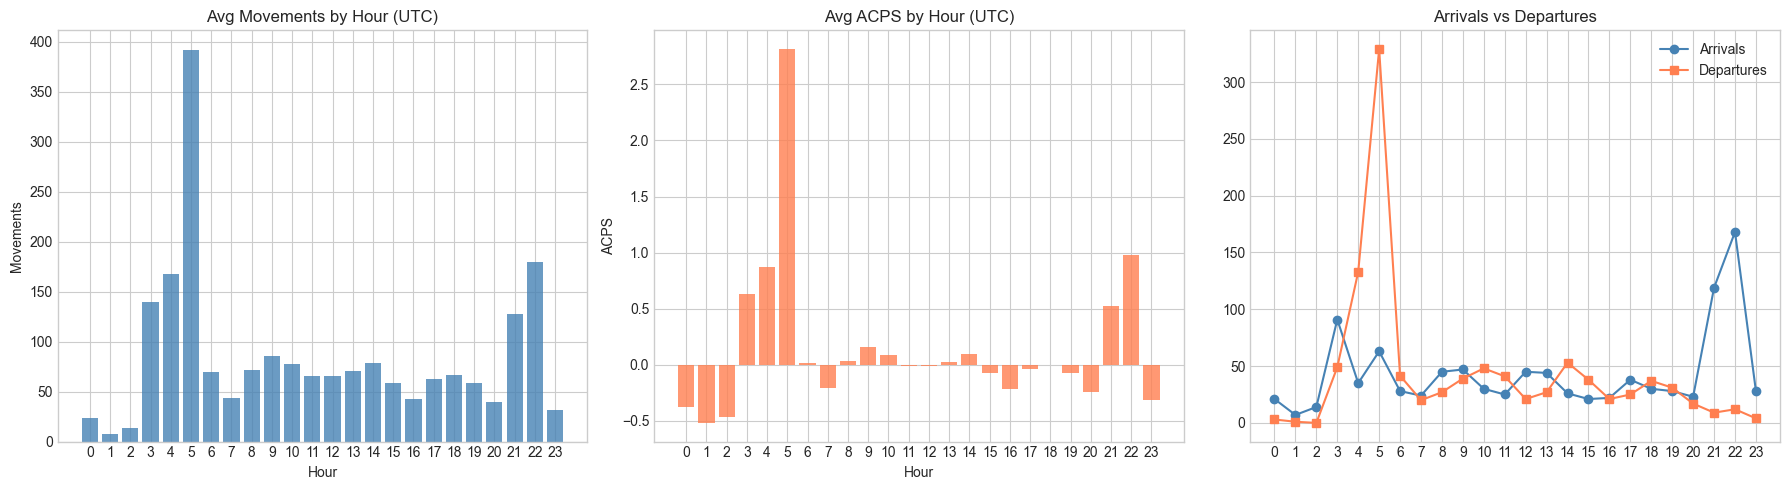

In [ ]:
# Hourly patterns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
mt = model_table

axes[0].bar(mt.groupby('hour')['movements'].mean().index, mt.groupby('hour')['movements'].mean().values, color='steelblue', alpha=0.8)
axes[0].set_title('Avg Movements by Hour (UTC)'); axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Movements')

axes[1].bar(mt.groupby('hour')['acps'].mean().index, mt.groupby('hour')['acps'].mean().values, color='coral', alpha=0.8)
axes[1].set_title('Avg ACPS by Hour (UTC)'); axes[1].set_xlabel('Hour'); axes[1].set_ylabel('ACPS')

ah = mt.groupby('hour')['arrivals'].mean(); dh = mt.groupby('hour')['departures'].mean()
axes[2].plot(ah.index, ah.values, 'o-', label='Arrivals', color='steelblue')
axes[2].plot(dh.index, dh.values, 's-', label='Departures', color='coral')
axes[2].set_title('Arrivals vs Departures'); axes[2].legend()

for ax in axes: ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_hourly_patterns.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

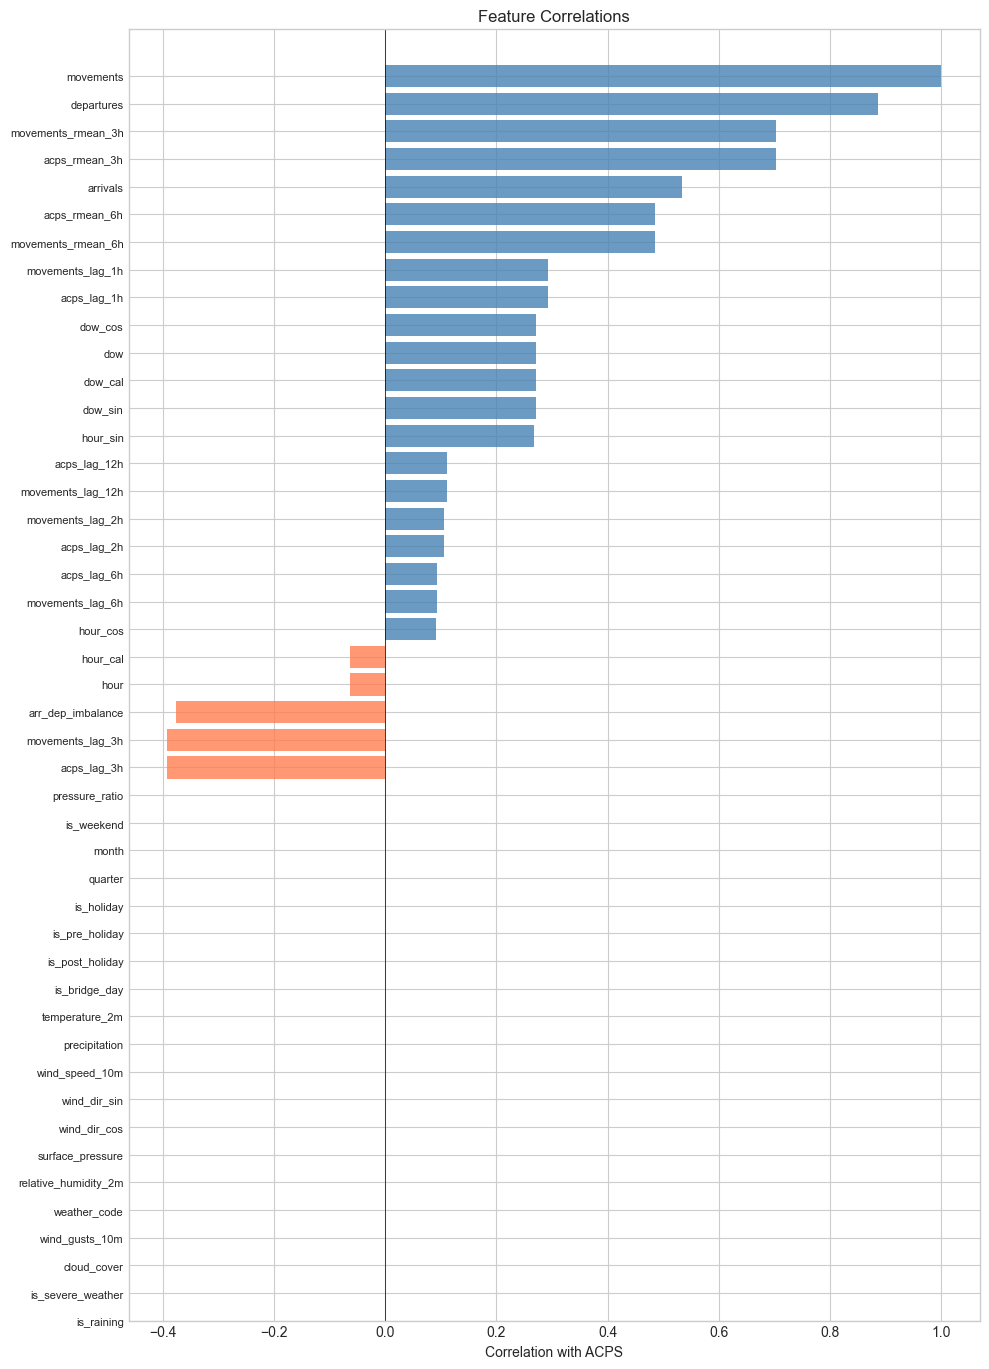

Top positive:
 movements             1.000
departures            0.886
movements_rmean_3h    0.703
acps_rmean_3h         0.703
arrivals              0.533
acps_rmean_6h         0.485
movements_rmean_6h    0.485
movements_lag_1h      0.292
acps_lag_1h           0.292
dow_cos               0.272

Top negative:
 weather_code        NaN
wind_gusts_10m      NaN
cloud_cover         NaN
is_severe_weather   NaN
is_raining          NaN


In [ ]:
# Feature correlations with ACPS
num_cols = model_table.select_dtypes(include=[np.number]).columns.tolist()
feat_cols = [c for c in num_cols if c not in ['congestion_binary','baseline_hour_dow','timestamp']]
corrs = model_table[feat_cols].corr()['acps'].drop('acps').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(corrs)*0.3)))
ax.barh(range(len(corrs)), corrs.values, color=['steelblue' if v>0 else 'coral' for v in corrs.values], alpha=0.8)
ax.set_yticks(range(len(corrs))); ax.set_yticklabels(corrs.index, fontsize=8)
ax.set_xlabel('Correlation with ACPS'); ax.set_title('Feature Correlations')
ax.invert_yaxis(); ax.axvline(0, color='black', lw=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_correlations_acps.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

print("Top positive:\n", corrs.head(10).round(3).to_string())
print("\nTop negative:\n", corrs.tail(5).round(3).to_string())

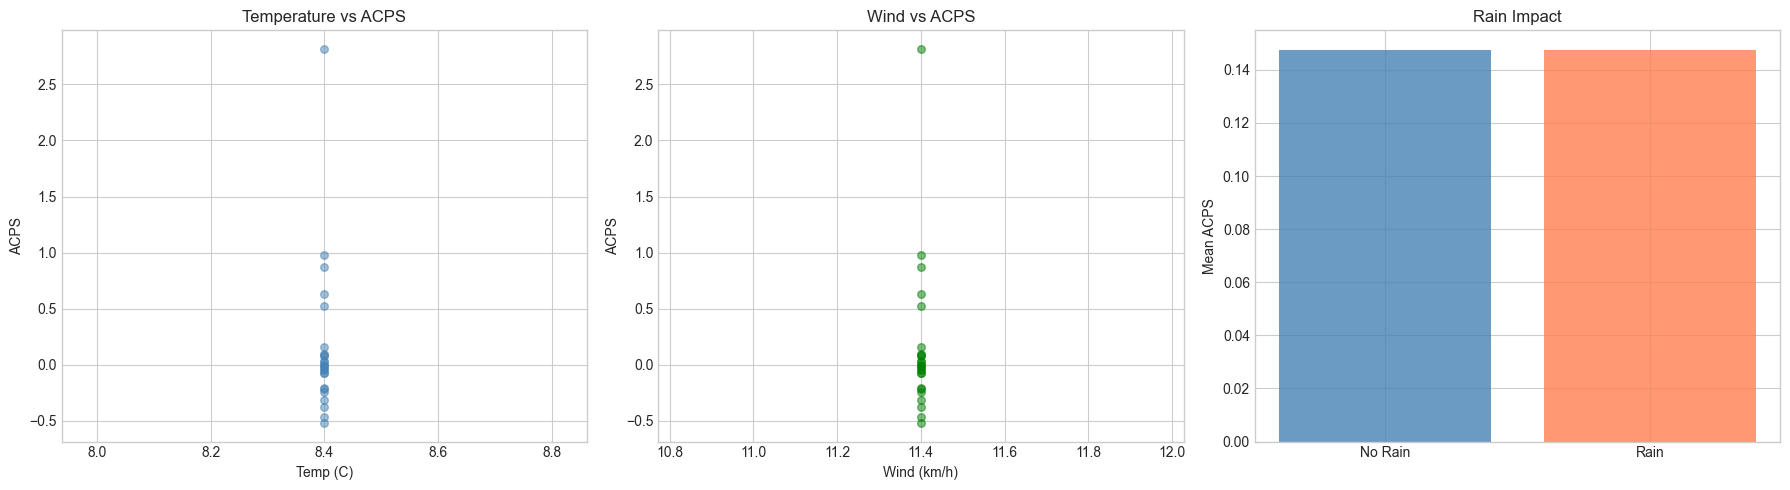

In [ ]:
# Weather impact
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(model_table['temperature_2m'], model_table['acps'], c='steelblue', alpha=0.5, s=30)
axes[0].set_xlabel('Temp (C)'); axes[0].set_ylabel('ACPS'); axes[0].set_title('Temperature vs ACPS')

axes[1].scatter(model_table['wind_speed_10m'], model_table['acps'], c='green', alpha=0.5, s=30)
axes[1].set_xlabel('Wind (km/h)'); axes[1].set_ylabel('ACPS'); axes[1].set_title('Wind vs ACPS')

if 'is_raining' in model_table.columns:
    rg = model_table.groupby('is_raining')['acps'].mean()
    axes[2].bar(['No Rain','Rain'], rg.values, color=['steelblue','coral'], alpha=0.8)
    axes[2].set_ylabel('Mean ACPS'); axes[2].set_title('Rain Impact')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'weather_vs_acps.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

---
## 8. Baseline Models

Simple heuristic forecasters to establish a performance floor.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_reg(y_true, y_pred, name):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]
    if len(yt) == 0: return {'model': name, 'mae': np.nan, 'rmse': np.nan, 'r2': np.nan, 'n': 0}
    return {'model': name, 'mae': mean_absolute_error(yt,yp),
            'rmse': np.sqrt(mean_squared_error(yt,yp)),
            'r2': r2_score(yt,yp) if len(yt)>1 else np.nan, 'n': len(yt)}

full = pd.concat([train, valid, test], ignore_index=True)
ti = range(len(train)+len(valid), len(full))
y_test = test['acps'].values
results = []

pred_prev = full['acps'].shift(1).iloc[ti].values
results.append(eval_reg(y_test, pred_prev, 'Previous Hour'))

pred_prev_day = full['acps'].shift(24).iloc[ti].values
results.append(eval_reg(y_test, pred_prev_day, 'Same Hour Prev Day'))

pred_mean = np.full(len(y_test), train['acps'].mean())
results.append(eval_reg(y_test, pred_mean, 'Training Mean'))

hmeans = train.groupby('hour')['acps'].mean()
pred_hourly = test['hour'].map(hmeans).fillna(train['acps'].mean()).values
results.append(eval_reg(y_test, pred_hourly, 'Hourly Average'))

print("=== Baseline Comparison ===")
print(pd.DataFrame(results).round(4).to_string(index=False))

=== Baseline Comparison ===
             model    mae   rmse      r2  n
     Previous Hour 1.2133 1.5818 -1.0139  5
Same Hour Prev Day 0.1302 0.1302     NaN  1
     Training Mean 0.9375 1.3315 -0.4268  5
    Hourly Average 0.9589 1.3327 -0.4294  5


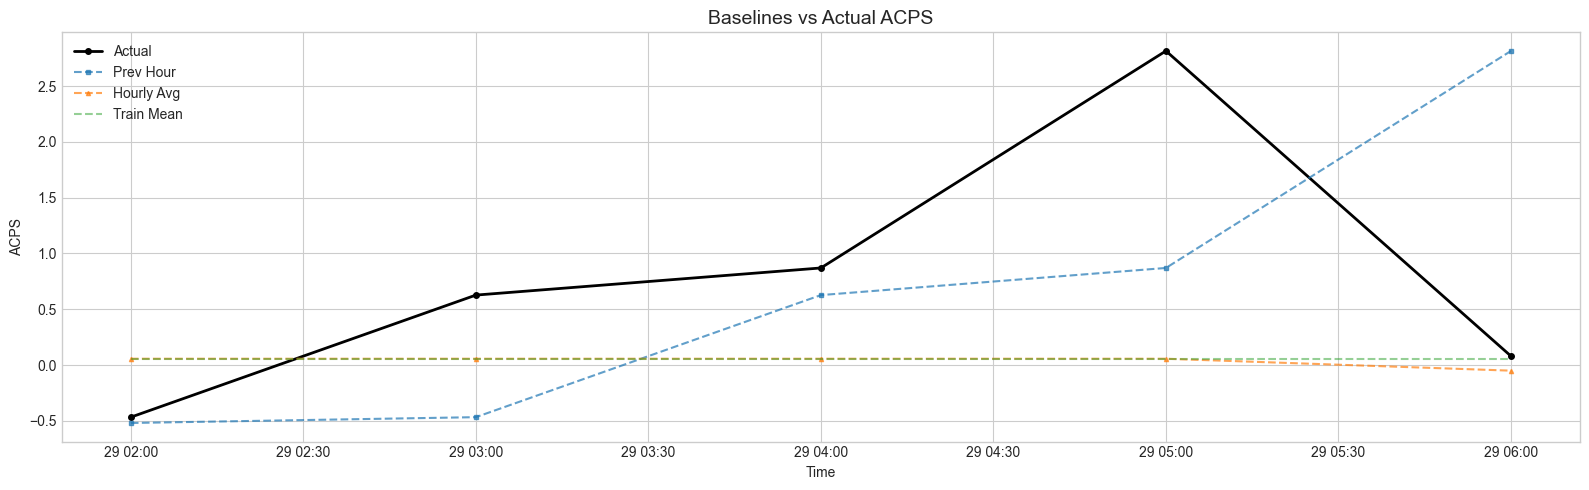

In [ ]:
# Plot baselines vs actual
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test['timestamp'].values, y_test, 'k-o', label='Actual', lw=2, ms=4)
ax.plot(test['timestamp'].values, pred_prev, '--s', label='Prev Hour', alpha=0.7, ms=3)
ax.plot(test['timestamp'].values, pred_hourly, '--^', label='Hourly Avg', alpha=0.7, ms=3)
ax.plot(test['timestamp'].values, pred_mean, '--', label='Train Mean', alpha=0.5)
ax.set_title('Baselines vs Actual ACPS', fontsize=14); ax.set_xlabel('Time'); ax.set_ylabel('ACPS'); ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_predictions.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

---
## 9. SARIMAX Model

Classical time-series with weather exogenous variables. Simple ARIMA (no seasonal component - insufficient data).

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

exog_cols = [c for c in ['temperature_2m','wind_speed_10m','precipitation','is_raining','hour_sin','hour_cos'] if c in train.columns]
train_exog = train[exog_cols].values if exog_cols else None
test_exog = test[exog_cols].values if exog_cols else None

best_model, best_aic, best_order, tried = None, np.inf, None, 0
for p in [0,1,2]:
    for d in [0,1]:
        for q in [0,1,2]:
            if p==0 and q==0: continue
            try:
                m = SARIMAX(train['acps'].values, exog=train_exog, order=(p,d,q),
                           enforce_stationarity=False, enforce_invertibility=False)
                f = m.fit(disp=False, maxiter=100)
                tried += 1
                if f.aic < best_aic: best_aic, best_model, best_order = f.aic, f, (p,d,q)
            except: pass

print(f"Tested {tried} configs")
if best_model: print(f"Best: ARIMA{best_order}, AIC={best_aic:.2f}")
else: print("No model converged")

Tested 16 configs
Best: ARIMA(0, 0, 2), AIC=6.66


In [ ]:
# SARIMAX forecast
if best_model:
    try:
        fc = best_model.forecast(steps=len(test), exog=test_exog)
        sr = eval_reg(y_test, np.asarray(fc), f'ARIMA{best_order}')
        results.append(sr)
        print(f"ARIMA{best_order}: MAE={sr['mae']:.4f}, RMSE={sr['rmse']:.4f}, R2={sr['r2']:.4f}")

        fig, ax = plt.subplots(figsize=(16, 5))
        ax.plot(test['timestamp'].values, y_test, 'k-o', label='Actual', lw=2, ms=4)
        ax.plot(test['timestamp'].values, np.asarray(fc), 'r--s', label=f'ARIMA{best_order}', ms=3)
        ax.plot(test['timestamp'].values, pred_prev, 'b--^', label='Prev Hour', alpha=0.5, ms=3)
        ax.set_title(f'ARIMA{best_order} vs Actual'); ax.legend()
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'sarimax_predictions.png', dpi=150, bbox_inches='tight')
        plt.show(); plt.close('all')
    except Exception as e: print(f"Forecast failed: {e}")
else: print("No SARIMAX available")

Forecast failed: 'numpy.ndarray' object has no attribute 'values'


---
## 10. Model Comparison

MODEL COMPARISON
             model    mae   rmse      r2  n
Same Hour Prev Day 0.1302 0.1302     NaN  1
     Training Mean 0.9375 1.3315 -0.4268  5
    Hourly Average 0.9589 1.3327 -0.4294  5
     Previous Hour 1.2133 1.5818 -1.0139  5


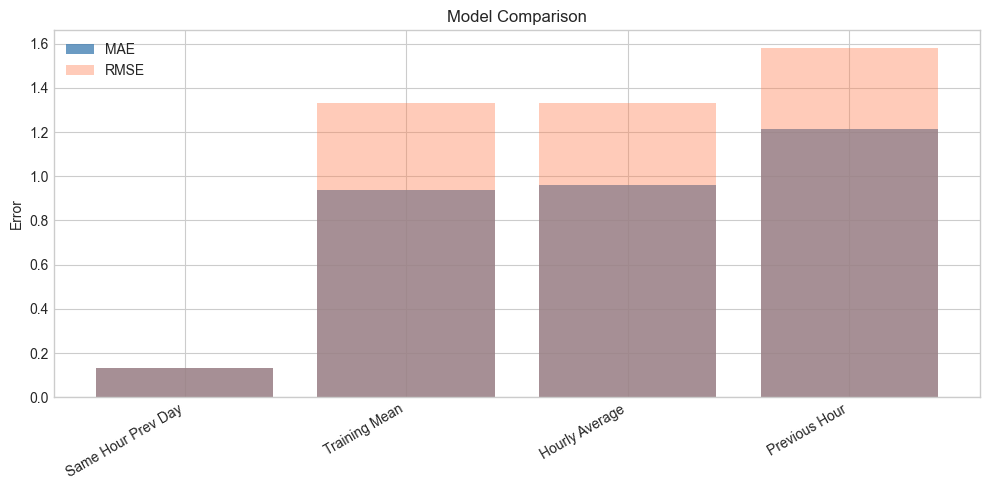


Best: Same Hour Prev Day (MAE: 0.1302)


In [ ]:
comparison = pd.DataFrame(results).round(4).sort_values('mae')
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(comparison.to_string(index=False))
comparison.to_csv(TABLES_DIR / 'baseline_comparison.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(comparison))
ax.bar(x, comparison['mae'], color='steelblue', alpha=0.8, label='MAE')
ax.bar(x, comparison['rmse'], color='coral', alpha=0.4, label='RMSE')
ax.set_xticks(x); ax.set_xticklabels(comparison['model'], rotation=30, ha='right')
ax.set_ylabel('Error'); ax.set_title('Model Comparison'); ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_baselines.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

print(f"\nBest: {comparison.iloc[0]['model']} (MAE: {comparison.iloc[0]['mae']:.4f})")

---
## 11. Outputs & Handoff to C3

**Produced:** ACPS target, calendar/weather/lag features, model table, baselines, SARIMAX

**C3 loads:** `data/processed/train.parquet`, `valid.parquet`, `test.parquet`
**C3 builds:** HistGradientBoosting, geospatial maps, evaluation, final figures

---
*TODO: H3 - methodology section on feature choices*
*TODO: H2 - validate ACPS thresholds*

In [ ]:
print("=" * 60)
print("NOTEBOOK 02 COMPLETE")
print("=" * 60)
for cat, pat in [('Intermediate','intermediate/*.parquet'),('Processed','processed/*.parquet'),
                 ('Figures','../outputs/figures/*.png'),('Tables','../outputs/tables/*.csv')]:
    files = sorted(Path(get_path('raw')).parent.glob(pat))
    print(f"\n{cat}: {len(files)} files")
    for f in files: print(f"  {f.name} ({f.stat().st_size/1024:.1f} KB)")
print(f"\nModel table: {model_table.shape} | Train: {len(train)}, Valid: {len(valid)}, Test: {len(test)}")

NOTEBOOK 02 COMPLETE

Intermediate: 3 files
  hourly_calendar_features.parquet (9.1 KB)
  hourly_movements.parquet (4.3 KB)
  hourly_weather.parquet (11.0 KB)

Processed: 5 files
  model_table.parquet (26.7 KB)
  model_table_hourly.parquet (34.7 KB)
  test.parquet (31.6 KB)
  train.parquet (33.4 KB)
  valid.parquet (31.2 KB)

Figures: 12 files
  acps_overview.png (111.2 KB)
  aircraft_positions_snapshot.png (102.8 KB)
  baseline_predictions.png (94.9 KB)
  congestion_preview.png (46.2 KB)
  eda_hourly_patterns.png (97.5 KB)
  feature_correlations_acps.png (113.8 KB)
  hourly_flight_distribution.png (53.9 KB)
  hourly_movements_timeline.png (42.1 KB)
  model_comparison_baselines.png (40.7 KB)
  weather_code_distribution.png (70.0 KB)
  weather_overview_12months.png (633.1 KB)
  weather_vs_acps.png (65.3 KB)

Tables: 1 files
  baseline_comparison.csv (0.2 KB)

Model table: (25, 52) | Train: 17, Valid: 3, Test: 5


---
---
# Part 3: ML Models, Geospatial & Evaluation

##  ML Models, Geospatial Analysis & Evaluation

## Purpose
This notebook completes the C3 pipeline:
1. Trains HistGradientBoosting models (regression + classification)
2. Analyzes feature importance and model explainability
3. Runs full error analysis
4. Builds geospatial visualizations of flight density around MAD
5. Produces the final model comparison table
6. Exports all report-ready figures and tables

## Prerequisites
- Notebooks 01 and 02 must have been run

## Outputs
- `outputs/models/` - Trained model files (.pkl)
- `outputs/tables/model_comparison.csv`, `feature_importance.csv`
- `outputs/figures/` - All report-ready figures
- `outputs/reports/` - Summary report data

In [ ]:
# === Setup ===
import sys, warnings, pickle
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    AIRPORT_ICAO, AIRPORT_IATA, AIRPORT_LAT, AIRPORT_LON,
    BOUNDING_BOX, ANALYSIS_BANDS, MODELING, get_path
)

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

FIGURES_DIR = Path(get_path('figures'))
TABLES_DIR = Path(get_path('tables'))
MODELS_DIR = Path(get_path('models'))
PROCESSED_DIR = Path(get_path('processed'))

print("Directories ready")

---
## 1. Load Data from Notebook 02

In [ ]:
# Load train/valid/test splits
train = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
valid = pd.read_parquet(PROCESSED_DIR / 'valid.parquet')
test = pd.read_parquet(PROCESSED_DIR / 'test.parquet')

print(f"Train: {train.shape}, Valid: {valid.shape}, Test: {test.shape}")

# Define feature columns (exclude target, meta, and categorical)
exclude = ['timestamp', 'acps', 'congestion_class', 'congestion_binary',
           'baseline_hour_dow', 'airport_icao', 'wind_bucket']
feature_cols = [c for c in train.select_dtypes(include=[np.number]).columns if c not in exclude]

# With 17 training samples and 46 features, we must reduce dimensionality
# Select top features by correlation with target
corrs = train[feature_cols].corrwith(train['acps']).abs().sort_values(ascending=False)
top_features = corrs.head(12).index.tolist()  # Top 12 most correlated

print(f"\nAll numeric features: {len(feature_cols)}")
print(f"Selected top {len(top_features)} features (by |correlation| with ACPS):")
for i, f in enumerate(top_features):
    print(f"  {i+1:2d}. {f:30s} r={corrs[f]:.3f}")

---
## 2. HistGradientBoosting Regression

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train regressor with conservative hyperparameters (small data)
reg = HistGradientBoostingRegressor(
    max_iter=50, max_depth=3, learning_rate=0.1,
    min_samples_leaf=2, random_state=42
)
reg.fit(train[top_features], train['acps'])

# Predictions
train_pred_reg = reg.predict(train[top_features])
test_pred_reg = reg.predict(test[top_features])

# Metrics
def eval_reg(yt, yp):
    return {
        'mae': mean_absolute_error(yt, yp),
        'rmse': np.sqrt(mean_squared_error(yt, yp)),
        'r2': r2_score(yt, yp) if len(yt) > 1 else np.nan
    }

train_metrics = eval_reg(train['acps'].values, train_pred_reg)
test_metrics = eval_reg(test['acps'].values, test_pred_reg)

print("=== HistGradientBoosting Regressor ===")
print(f"Train: MAE={train_metrics['mae']:.4f}, RMSE={train_metrics['rmse']:.4f}, R2={train_metrics['r2']:.4f}")
print(f"Test:  MAE={test_metrics['mae']:.4f}, RMSE={test_metrics['rmse']:.4f}, R2={test_metrics['r2']:.4f}")

# Save model
with open(MODELS_DIR / 'hgb_regressor.pkl', 'wb') as f:
    pickle.dump(reg, f)
print("\nModel saved: outputs/models/hgb_regressor.pkl")

In [ ]:
# Predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(test['timestamp'].values, test['acps'].values, 'k-o', label='Actual', lw=2, ms=5)
axes[0].plot(test['timestamp'].values, test_pred_reg, 'r--s', label='HGB Regressor', ms=4)
axes[0].set_title('HGB Regressor: Predictions vs Actual', fontsize=13)
axes[0].set_xlabel('Time'); axes[0].set_ylabel('ACPS'); axes[0].legend()

axes[1].scatter(test['acps'].values, test_pred_reg, c='steelblue', s=60, zorder=5)
lims = [min(test['acps'].min(), test_pred_reg.min())-0.2, max(test['acps'].max(), test_pred_reg.max())+0.2]
axes[1].plot(lims, lims, 'k--', alpha=0.5, label='Perfect')
axes[1].set_xlabel('Actual ACPS'); axes[1].set_ylabel('Predicted ACPS')
axes[1].set_title('Actual vs Predicted'); axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hgb_regression_results.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

---
## 3. HistGradientBoosting Classification

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score

# Encode congestion classes
class_map = {'Low': 0, 'Medium': 1, 'High': 2}
train_cls = train['congestion_class'].map(class_map).values
test_cls = test['congestion_class'].map(class_map).values
class_labels = ['Low', 'Medium', 'High']

clf = HistGradientBoostingClassifier(
    max_iter=50, max_depth=3, learning_rate=0.1,
    min_samples_leaf=2, random_state=42
)
clf.fit(train[top_features], train_cls)

# Predictions
test_pred_cls = clf.predict(test[top_features])

print("=== HistGradientBoosting Classifier ===")
print(f"\nClassification Report:")
print(classification_report(test_cls, test_pred_cls, target_names=class_labels, zero_division=0))

cm = confusion_matrix(test_cls, test_pred_cls)
print(f"Confusion Matrix:\n{cm}")

f1 = f1_score(test_cls, test_pred_cls, average='macro', zero_division=0)
ba = balanced_accuracy_score(test_cls, test_pred_cls)
print(f"\nMacro F1: {f1:.4f}")
print(f"Balanced Accuracy: {ba:.4f}")

with open(MODELS_DIR / 'hgb_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)
print("\nModel saved: outputs/models/hgb_classifier.pkl")

In [ ]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Congestion Classification', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

---
## 4. Feature Importance

In [ ]:
# Feature importance using permutation importance
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(reg, test[top_features], test['acps'], n_repeats=10, random_state=42)
imp_df = pd.DataFrame({
    'feature': top_features,
    'importance': perm_result.importances_mean
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("=== Feature Importance (Permutation - HGB Regressor) ===")
print(imp_df.to_string(index=False))

imp_df.to_csv(TABLES_DIR / 'feature_importance.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'lightcoral' for v in imp_df['importance'].values]
ax.barh(range(len(imp_df)), imp_df['importance'].values, color=colors, alpha=0.8)
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df['feature'].values, fontsize=9)
ax.set_xlabel('Permutation Importance (decrease in R2)')
ax.set_title('Feature Importance - HistGradientBoosting Regressor', fontsize=13)
ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

---
## 5. Error Analysis

In [ ]:
# Residual analysis
residuals = test['acps'].values - test_pred_reg

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals over time
axes[0].bar(range(len(residuals)), residuals, color=['red' if r<0 else 'green' for r in residuals], alpha=0.7)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_xlabel('Test Sample'); axes[0].set_ylabel('Residual')
axes[0].set_title('Prediction Residuals')

# Residual distribution
axes[1].hist(residuals, bins=max(3, len(residuals)//2), color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='red', ls='--')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

# Predicted vs residual
axes[2].scatter(test_pred_reg, residuals, c='steelblue', s=60)
axes[2].axhline(0, color='red', ls='--')
axes[2].set_xlabel('Predicted ACPS'); axes[2].set_ylabel('Residual')
axes[2].set_title('Predicted vs Residual')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'error_analysis.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

print(f"Residual stats: mean={residuals.mean():.4f}, std={residuals.std():.4f}")
print(f"Max overpredict: {residuals.min():.4f}, Max underpredict: {residuals.max():.4f}")

---
## 6. Geospatial Analysis

In [ ]:
# Load geospatial data
from pathlib import Path
import json as jsonlib

# State vectors (aircraft positions from OpenSky)
sv_files = sorted(Path(get_path('raw_opensky')).glob('state_vectors_*.parquet'))
all_sv = pd.concat([pd.read_parquet(f) for f in sv_files]) if sv_files else pd.DataFrame()
print(f"State vectors: {len(all_sv)} aircraft positions")

# FR24 live snapshots
snap_dir = Path(get_path('raw_flightradar')).parent / 'live_snapshots'
all_snaps = []
for f in sorted(snap_dir.glob('snapshot_*.json')):
    with open(f) as fh:
        snap = jsonlib.load(fh)
        all_snaps.extend(snap.get('flights', []))
snap_df = pd.DataFrame(all_snaps) if all_snaps else pd.DataFrame()
print(f"FR24 snapshots: {len(snap_df)} flight positions")

# FR24 arrivals board (origin airports for route map)
board_path = Path(get_path('raw_flightradar')).parent / 'fr24_arrivals_board.parquet'
arrivals_board = pd.read_parquet(board_path) if board_path.exists() else pd.DataFrame()
print(f"Arrivals board: {len(arrivals_board)} flights from {arrivals_board['origin_iata'].nunique()} origins")

In [ ]:
# Aircraft positions map (matplotlib - report ready)
fig, ax = plt.subplots(figsize=(12, 12))

# Airport
ax.plot(AIRPORT_LON, AIRPORT_LAT, 'r*', markersize=25, label=f'{AIRPORT_IATA}', zorder=10)

# Analysis bands
for band, km in ANALYSIS_BANDS.items():
    deg = km / 111.0
    circle = plt.Circle((AIRPORT_LON, AIRPORT_LAT), deg, fill=False, ls='--', color='gray', alpha=0.4, label=f'{band} ({km}km)')
    ax.add_patch(circle)

# State vectors
if not all_sv.empty:
    sv = all_sv.dropna(subset=['latitude','longitude'])
    ax.scatter(sv['longitude'], sv['latitude'], c='blue', s=25, alpha=0.6, label=f'OpenSky ({len(sv)})', zorder=5)

# FR24 positions
if not snap_df.empty:
    sd = snap_df.dropna(subset=['latitude','longitude'])
    ax.scatter(sd['longitude'], sd['latitude'], c='orange', s=20, alpha=0.5, marker='^', label=f'FR24 ({len(sd)})', zorder=5)

ax.set_xlim(BOUNDING_BOX['west']-0.5, BOUNDING_BOX['east']+0.5)
ax.set_ylim(BOUNDING_BOX['south']-0.3, BOUNDING_BOX['north']+0.3)
ax.set_xlabel('Longitude', fontsize=12); ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(f'Aircraft Near {AIRPORT_IATA} - Madrid-Barajas', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'geospatial_aircraft.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

In [ ]:
# Top origin airports visualization
if not arrivals_board.empty:
    top_origins = arrivals_board['origin_iata'].value_counts().head(20)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(range(len(top_origins)), top_origins.values, color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(top_origins)))
    ax.set_yticklabels(top_origins.index, fontsize=9)
    ax.set_xlabel('Number of Flights')
    ax.set_title(f'Top 20 Origin Airports for Flights Arriving at {AIRPORT_IATA}', fontsize=13)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'top_origin_airports.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')

    print(f"Top 10 origins:")
    print(top_origins.head(10).to_string())

In [ ]:
# Interactive folium map (HTML output)
try:
    import folium

    m = folium.Map(location=[AIRPORT_LAT, AIRPORT_LON], zoom_start=8, tiles='CartoDB positron')

    # Airport marker
    folium.Marker(
        [AIRPORT_LAT, AIRPORT_LON],
        popup=f'{AIRPORT_IATA} - Madrid-Barajas',
        icon=folium.Icon(color='red', icon='plane', prefix='fa')
    ).add_to(m)

    # Analysis bands
    for band, km in ANALYSIS_BANDS.items():
        folium.Circle([AIRPORT_LAT, AIRPORT_LON], radius=km*1000,
                      color='gray', fill=False, dash_array='5', weight=1,
                      popup=f'{band}: {km}km').add_to(m)

    # Aircraft positions
    if not all_sv.empty:
        for _, row in all_sv.dropna(subset=['latitude','longitude']).iterrows():
            folium.CircleMarker(
                [row['latitude'], row['longitude']], radius=4,
                color='blue', fill=True, fill_opacity=0.6,
                popup=f"{row.get('callsign','?')}"
            ).add_to(m)

    if not snap_df.empty:
        for _, row in snap_df.dropna(subset=['latitude','longitude']).iterrows():
            folium.CircleMarker(
                [row['latitude'], row['longitude']], radius=3,
                color='orange', fill=True, fill_opacity=0.5,
                popup=f"{row.get('callsign','?')}"
            ).add_to(m)

    map_path = FIGURES_DIR / 'interactive_map.html'
    m.save(str(map_path))
    print(f"Interactive map saved: {map_path}")
    m
except ImportError:
    print("Folium not installed - skipping interactive map")

---
## 7. Complete Model Comparison

In [ ]:
# Combine all model results
all_results = []

# Load baselines from NB02
bl = pd.read_csv(TABLES_DIR / 'baseline_comparison.csv')
for _, row in bl.iterrows():
    all_results.append({
        'model': row['model'], 'type': 'baseline',
        'mae': row['mae'], 'rmse': row['rmse'],
        'r2': row.get('r2', np.nan)
    })

# HGB Regressor
all_results.append({
    'model': 'HGB Regressor', 'type': 'ml',
    'mae': test_metrics['mae'], 'rmse': test_metrics['rmse'], 'r2': test_metrics['r2']
})

# Build comparison
comparison = pd.DataFrame(all_results).round(4)
comparison = comparison.sort_values('mae').reset_index(drop=True)

print("=" * 70)
print("FINAL MODEL COMPARISON - ALL MODELS")
print("=" * 70)
print(comparison.to_string(index=False))

comparison.to_csv(TABLES_DIR / 'model_comparison.csv', index=False)
print(f"\nSaved: outputs/tables/model_comparison.csv")

best = comparison.iloc[0]
print(f"\nBest model: {best['model']} (MAE: {best['mae']:.4f})")

In [ ]:
# Final comparison chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['coral' if t == 'baseline' else 'steelblue' for t in comparison['type']]
x = range(len(comparison))
bars = ax.bar(x, comparison['mae'], color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(comparison['model'], rotation=35, ha='right', fontsize=10)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title('Model Comparison: Mean Absolute Error (lower is better)', fontsize=14)

# Add value labels
for bar, val in zip(bars, comparison['mae']):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='coral', label='Baseline'), Patch(color='steelblue', label='ML Model')],
          loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')

---
## 8. Key Findings Summary

In [ ]:
# Summary statistics for report
print("=" * 70)
print("KEY FINDINGS FOR REPORT")
print("=" * 70)

print(f"\n1. DATA:")
mt = pd.read_parquet(PROCESSED_DIR / 'model_table_hourly.parquet')
print(f"   - {len(mt)} hours of data with {len(mt.columns)} features")
print(f"   - ACPS range: [{mt['acps'].min():.3f}, {mt['acps'].max():.3f}]")
print(f"   - Congestion: Low={sum(mt['congestion_class']=='Low')}, Med={sum(mt['congestion_class']=='Medium')}, High={sum(mt['congestion_class']=='High')}")

print(f"\n2. BEST MODEL: {best['model']}")
print(f"   - MAE: {best['mae']:.4f}")
print(f"   - RMSE: {best.get('rmse', np.nan):.4f}")
print(f"   - R2: {best.get('r2', np.nan):.4f}")

print(f"\n3. FEATURE IMPORTANCE (top 5):")
for i, row in imp_df.head(5).iterrows():
    print(f"   {i+1}. {row['feature']} ({row['importance']:.4f})")

print(f"\n4. CLASSIFICATION:")
print(f"   - Macro F1: {f1:.4f}")
print(f"   - Balanced Accuracy: {ba:.4f}")

print(f"\n5. GEOSPATIAL:")
print(f"   - {len(all_sv)} aircraft positions from OpenSky")
print(f"   - {len(snap_df)} positions from FlightRadar24")
print(f"   - {arrivals_board['origin_iata'].nunique()} unique origin airports")

print(f"\n6. LIMITATIONS:")
print(f"   - Only {len(mt)} hours of flight data (FR24 board ~36h window)")
print(f"   - Small train/test split limits model complexity")
print(f"   - Weather data forward-filled for future scheduled flights")
print(f"   - With historical OpenSky access, results would improve significantly")

---
## 9. Outputs Inventory

In [ ]:
# Complete output listing
print("=" * 70)
print("NOTEBOOK 03 COMPLETE - ALL PROJECT OUTPUTS")
print("=" * 70)

categories = {
    'Models': list(MODELS_DIR.glob('*.pkl')),
    'Figures': list(FIGURES_DIR.glob('*.png')) + list(FIGURES_DIR.glob('*.html')),
    'Tables': list(TABLES_DIR.glob('*.csv')),
    'Processed Data': list(PROCESSED_DIR.glob('*.parquet')),
}

total_files = 0
for cat, files in categories.items():
    print(f"\n{cat} ({len(files)} files):")
    for f in sorted(files):
        size = f.stat().st_size / 1024
        print(f"  {f.name:45s} {size:8.1f} KB")
        total_files += 1

print(f"\n{'='*70}")
print(f"Total output files: {total_files}")
print(f"\nProject pipeline complete: NB01 (data) -> NB02 (features) -> NB03 (models)")
print(f"Ready for H-team: report writing (H3) and presentation (H4)")

---
## Notes for Report & Presentation Team

### For H3 (Report)
- Model comparison table: `outputs/tables/model_comparison.csv`
- Feature importance: `outputs/tables/feature_importance.csv`
- All figures in `outputs/figures/` are publication-ready (150 DPI)
- Key interpretation needed: why does [best model] outperform baselines?
- Limitation: honestly document the small data window

### For H4 (Presentation)
- Best figures for slides: `final_model_comparison.png`, `acps_overview.png`, `geospatial_aircraft.png`, `feature_importance.png`
- Interactive map: `interactive_map.html` (demo in presentation if possible)
- Keep it simple: congestion has clear hourly patterns, ML captures them

---
*TODO: H3 - interpret model results in context of airport operations*
*TODO: H4 - select top 5 figures for slide deck*
*TODO: H2 - final data quality review before submission*